<a href="https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/02_task2_finetune_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TÖL506M - Introduction to Deep Neural Network
## Final Project: Wildlife Image Classification
### Task 2 - Fine-tuning a Pretrained Model

**name:** Luiza V Sampaio Ramos, **email:** lvs2@gmail.com

This notebook is has the same process as [02_task2_finetune.ipynb](https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/02_task2_finetune.ipynb) and [02_task2_finetune_3.ipynb](https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/02_task2_finetune_3.ipynb) with only the difference being the random seed set. Which for this notebook the seed is 42.

In this notebook, a classification model is fine-tuned given a previous pretrained one. The model uses the dataset [Animals-10](https://www.kaggle.com/datasets/alessiocorrado99/animals10) and the data split analised in the previous notebook([00_data_exploration.ipynb](https://github.com/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/00_data_exploration.ipynb) and [01_task1_scratch.ipynb](https://github.com/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/01_task1_scratch.ipynb)). The tuning is performed independantly over different fractions of the training database (10%, 25%, 50%, 75% and 100%), and the summary of metrics and plots are shown and downloaded in a zip format.

Observe that the first six (6) cells of code bellow were implemented to be able to run the notebook using Google Colab mantainig it connected to the GitHub project. The rest o the code was initially wroten using DataSpell.

In [1]:
!rm -rf /content/TOL506M_Final_Project

In [2]:
import os, sys, subprocess

REPO_URL = "https://github.com/LuizaRamos/TOL506M_Final_Project.git"
REPO_DIR = "/content/TOL506M_Final_Project"

# Always clone fresh in Colab
subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["PYTHONPATH"] = REPO_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

In [3]:
import sys
import os
import subprocess
import importlib
import json
import time
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import Counter
from PIL import Image
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
from torchvision import datasets, transforms
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

project_root = Path.cwd()
if project_root.name != "TOL506M_Final_Project":
    original = project_root
    while project_root.name != "TOL506M_Final_Project" and project_root != project_root.parent:
        project_root = project_root.parent

    if project_root.name == "TOL506M_Final_Project":
        os.chdir(project_root)
        print(f"Changed working directory from {original} to {project_root}")
    else:
        raise RuntimeError(
            "Could not locate the TOL506M_Final_Project root directory. "
            "Please run this notebook/script from within the project tree."
        )
else:
    print(f"Working directory: {project_root}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Plot styling
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12})

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Working directory: /content/TOL506M_Final_Project

PyTorch version: 2.9.0+cu126
CUDA available: True


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print(f'Dataset downloaded: {path}\n')

Using Colab cache for faster access to the 'animals10' dataset.
Dataset downloaded: /kaggle/input/animals10



In [5]:
# Import project modules
from config import Config
from data.dataset import (WildlifeDataset, SplitIndices, stratified_split,
                          compute_class_counts, materialize_split, is_italian,
                          translate_names, get_class_names, get_data_loaders)
from data.augmentation import get_train_transforms, get_val_transforms
from models.resnet_scratch import ResNet18Scratch
from tasks.task2 import fine_tune_pretrained
from utils.training import train_epoch, validate, EarlyStopping
from utils.evaluation import evaluate_model, get_confusion_matrix, compute_metrics
from utils.visualization import plot_training_curves, plot_confusion_matrix

data_fractions = Config.DATA_FRACTIONS
train_size = Config.TRAIN_SPLIT
val_size = Config.VAL_SPLIT
test_size = Config.TEST_SPLIT
Config.RANDOM_SEED = 42
random_seed = Config.RANDOM_SEED

data_path = Path(path) / 'raw-img'
Config.DATA_PATH = data_path

basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Download and split dataset as previously done on previous notebooks
full_dataset = datasets.ImageFolder(root=str(data_path), transform=basic_transform)
dataset_transformed = translate_names(full_dataset)

wildlife = WildlifeDataset(str(data_path), transform=None)
train_idx_base, val_idx_fixed, test_idx_fixed = stratified_split(
    full_dataset,
    train_size=train_size,
    val_size=val_size,
    test_size=test_size,
    random_seed=random_seed
)

fixed = SplitIndices(train=train_idx_base, val=val_idx_fixed, test=test_idx_fixed)

print(f'Total images: {len(wildlife)}')
print(f'Base Train images: {len(train_idx_base)}')
print(f'Validation images: {len(val_idx_fixed)}')
print(f'Test images: {len(test_idx_fixed)}')

Total images: 26179
Base Train images: 18325
Validation images: 3927
Test images: 3927


In [6]:
# Create output dirs if they don't exist
Config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
Config.PLOTS_DIR.mkdir(parents=True, exist_ok=True)
Config.METRICS_DIR.mkdir(parents=True, exist_ok=True)


Starting training with freezing mode all_but_fc


Starting training for data fraction = 10%

Training on 10 classes.
Training samples: 1832.
Validation samples: 3927.
Test samples: 3927.
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 203MB/s]


Trainable parameters: 5,130/11,181,642


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.79it/s]



 Epoch 1/50:
 Train Loss: 1.6636, Train Accuracy: 48.91%
 Val Loss: 0.9864, Val Accuracy: 77.01%
Saved best model (Val Acc: 77.01%).


...

Validation: 100%|██████████| 62/62 [00:09<00:00,  6.84it/s]



 Epoch 38/50:
 Train Loss: 0.1648, Train Accuracy: 95.47%
 Val Loss: 0.2078, Val Accuracy: 93.61%


Validation: 100%|██████████| 62/62 [00:08<00:00,  6.89it/s]


 Epoch 39/50:
 Train Loss: 0.1660, Train Accuracy: 95.85%
 Val Loss: 0.2094, Val Accuracy: 93.56%
Early stopping triggered at epoch 39.
Training completed in 712.75 seconds.



 Test Results: 
 Accuracy: 93.10%
 Precision: 93.32%
 Recall: 93.10%
 F1-score: 93.07%


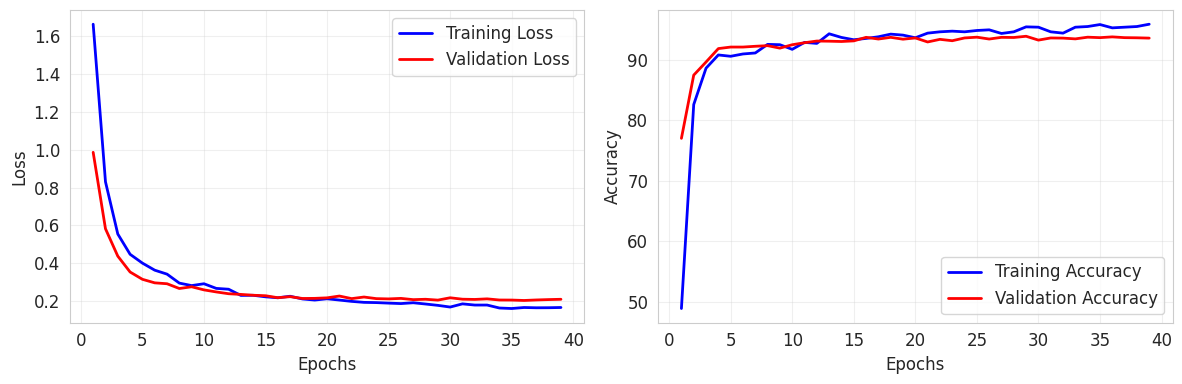


Starting training for data fraction = 25%

Training on 10 classes.
Training samples: 4581.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 5,130/11,181,642


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.76it/s]



 Epoch 1/50:
 Train Loss: 1.1084, Train Accuracy: 70.68%
 Val Loss: 0.4766, Val Accuracy: 89.79%
Saved best model (Val Acc: 89.79%).


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.88it/s]



 Epoch 2/50:
 Train Loss: 0.4642, Train Accuracy: 88.98%
 Val Loss: 0.3136, Val Accuracy: 91.52%
Saved best model (Val Acc: 91.52%).


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  7.27it/s]



 Epoch 22/50:
 Train Loss: 0.1765, Train Accuracy: 94.83%
 Val Loss: 0.1876, Val Accuracy: 94.17%


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.37it/s]


 Epoch 23/50:
 Train Loss: 0.1857, Train Accuracy: 94.24%
 Val Loss: 0.1794, Val Accuracy: 94.53%
Early stopping triggered at epoch 23.
Training completed in 731.69 seconds.



 Test Results: 
 Accuracy: 94.40%
 Precision: 94.47%
 Recall: 94.40%
 F1-score: 94.37%


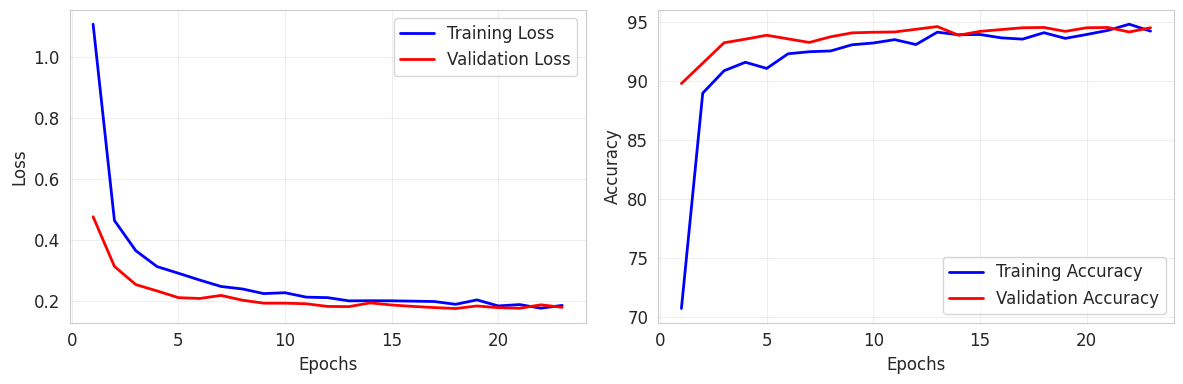


Starting training for data fraction = 50%

Training on 10 classes.
Training samples: 9162.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 5,130/11,181,642


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.14it/s]



 Epoch 1/50:
 Train Loss: 0.8148, Train Accuracy: 78.07%
 Val Loss: 0.3178, Val Accuracy: 91.24%
Saved best model (Val Acc: 91.24%).


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.35it/s]



 Epoch 2/50:
 Train Loss: 0.3371, Train Accuracy: 90.93%
 Val Loss: 0.2311, Val Accuracy: 93.66%
Saved best model (Val Acc: 93.66%).


...

Validation: 100%|██████████| 62/62 [00:09<00:00,  6.59it/s]



 Epoch 33/50:
 Train Loss: 0.1702, Train Accuracy: 94.28%
 Val Loss: 0.1573, Val Accuracy: 95.31%


Validation: 100%|██████████| 62/62 [00:08<00:00,  6.94it/s]


 Epoch 34/50:
 Train Loss: 0.1630, Train Accuracy: 94.87%
 Val Loss: 0.1650, Val Accuracy: 95.01%
Early stopping triggered at epoch 34.
Training completed in 1834.26 seconds.



 Test Results: 
 Accuracy: 94.50%
 Precision: 94.57%
 Recall: 94.50%
 F1-score: 94.48%


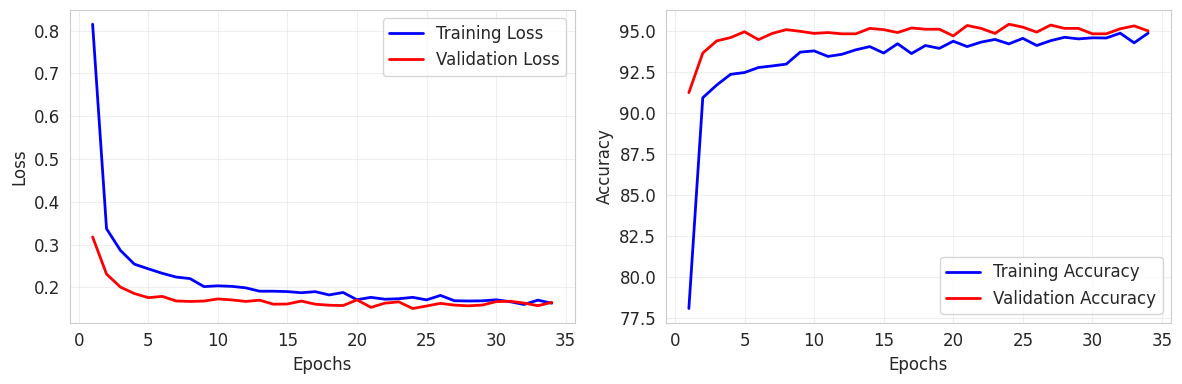


Starting training for data fraction = 75%

Training on 10 classes.
Training samples: 13743.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 5,130/11,181,642


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.70it/s]



 Epoch 1/50:
 Train Loss: 0.6460, Train Accuracy: 83.06%
 Val Loss: 0.2527, Val Accuracy: 92.95%
Saved best model (Val Acc: 92.95%).


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.26it/s]



 Epoch 2/50:
 Train Loss: 0.2947, Train Accuracy: 91.58%
 Val Loss: 0.2251, Val Accuracy: 93.25%
Saved best model (Val Acc: 93.25%).


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  7.35it/s]



 Epoch 31/50:
 Train Loss: 0.1647, Train Accuracy: 94.74%
 Val Loss: 0.1541, Val Accuracy: 95.42%


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.29it/s]


 Epoch 32/50:
 Train Loss: 0.1635, Train Accuracy: 94.73%
 Val Loss: 0.1576, Val Accuracy: 95.39%
Early stopping triggered at epoch 32.
Training completed in 2440.60 seconds.



 Test Results: 
 Accuracy: 95.19%
 Precision: 95.21%
 Recall: 95.19%
 F1-score: 95.18%


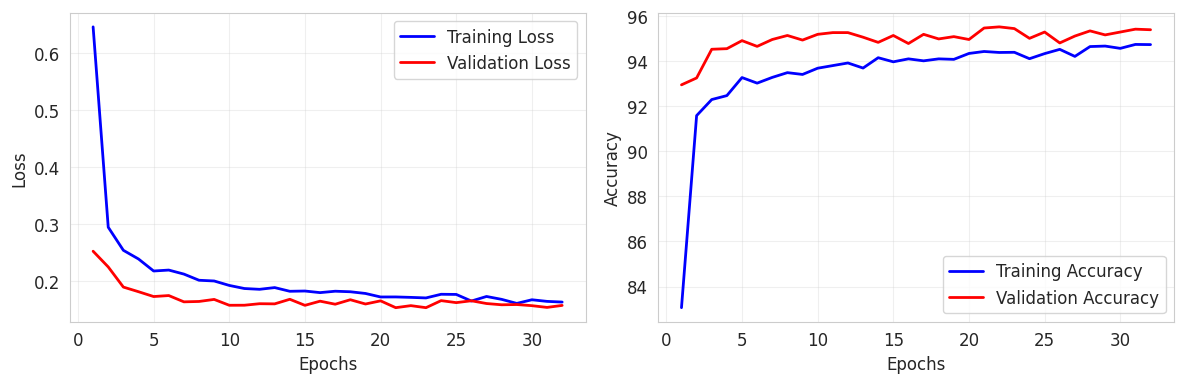


Starting training for data fraction = 100%

Training on 10 classes.
Training samples: 18325.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 5,130/11,181,642


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.35it/s]



 Epoch 1/50:
 Train Loss: 0.5730, Train Accuracy: 84.52%
 Val Loss: 0.2370, Val Accuracy: 93.43%
Saved best model (Val Acc: 93.43%).


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.85it/s]



 Epoch 2/50:
 Train Loss: 0.2710, Train Accuracy: 91.86%
 Val Loss: 0.1776, Val Accuracy: 95.03%
Saved best model (Val Acc: 95.03%).


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  7.26it/s]



 Epoch 45/50:
 Train Loss: 0.1600, Train Accuracy: 94.83%
 Val Loss: 0.1492, Val Accuracy: 95.70%


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.26it/s]


 Epoch 46/50:
 Train Loss: 0.1561, Train Accuracy: 94.75%
 Val Loss: 0.1464, Val Accuracy: 95.75%
Early stopping triggered at epoch 46.
Training completed in 4575.92 seconds.



 Test Results: 
 Accuracy: 95.09%
 Precision: 95.11%
 Recall: 95.09%
 F1-score: 95.08%


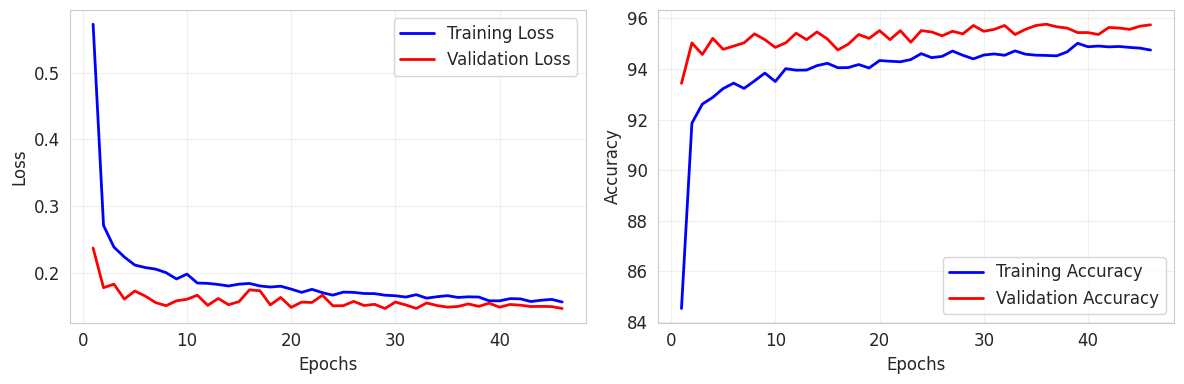


Finished training for all fractions for freeze mode all_but_fc.


Starting training with freezing mode up_to_layer1


Starting training for data fraction = 10%

Training on 10 classes.
Training samples: 1832.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 11,024,138/11,181,642


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.06it/s]



 Epoch 1/50:
 Train Loss: 0.8231, Train Accuracy: 73.09%
 Val Loss: 1.7259, Val Accuracy: 64.50%
Saved best model (Val Acc: 64.50%).


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.15it/s]



 Epoch 2/50:
 Train Loss: 0.4603, Train Accuracy: 85.15%
 Val Loss: 0.7869, Val Accuracy: 75.66%
Saved best model (Val Acc: 75.66%).


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  7.01it/s]



 Epoch 49/50:
 Train Loss: 0.0019, Train Accuracy: 100.00%
 Val Loss: 0.3851, Val Accuracy: 89.97%


Validation: 100%|██████████| 62/62 [00:08<00:00,  6.91it/s]


 Epoch 50/50:
 Train Loss: 0.0015, Train Accuracy: 100.00%
 Val Loss: 0.3891, Val Accuracy: 89.89%
Training completed in 908.68 seconds.



 Test Results: 
 Accuracy: 89.51%
 Precision: 89.73%
 Recall: 89.51%
 F1-score: 89.47%


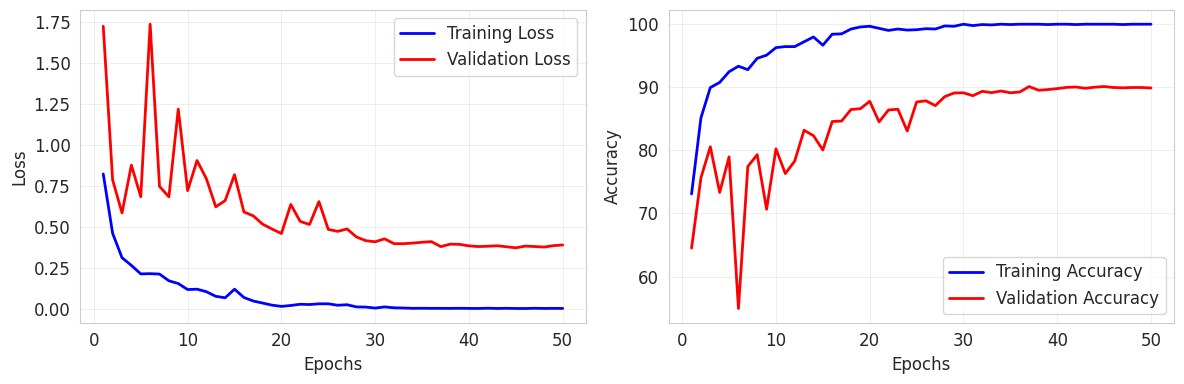


Starting training for data fraction = 25%

Training on 10 classes.
Training samples: 4581.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 11,024,138/11,181,642


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.82it/s]



 Epoch 1/50:
 Train Loss: 0.6976, Train Accuracy: 77.12%
 Val Loss: 0.5598, Val Accuracy: 81.08%
Saved best model (Val Acc: 81.08%).


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.53it/s]



 Epoch 2/50:
 Train Loss: 0.4463, Train Accuracy: 85.68%
 Val Loss: 0.8254, Val Accuracy: 73.72%


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  7.28it/s]



 Epoch 49/50:
 Train Loss: 0.0020, Train Accuracy: 99.96%
 Val Loss: 0.2972, Val Accuracy: 92.41%


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.13it/s]


 Epoch 50/50:
 Train Loss: 0.0018, Train Accuracy: 99.96%
 Val Loss: 0.2971, Val Accuracy: 92.51%
Training completed in 1591.69 seconds.



 Test Results: 
 Accuracy: 91.85%
 Precision: 91.91%
 Recall: 91.85%
 F1-score: 91.83%


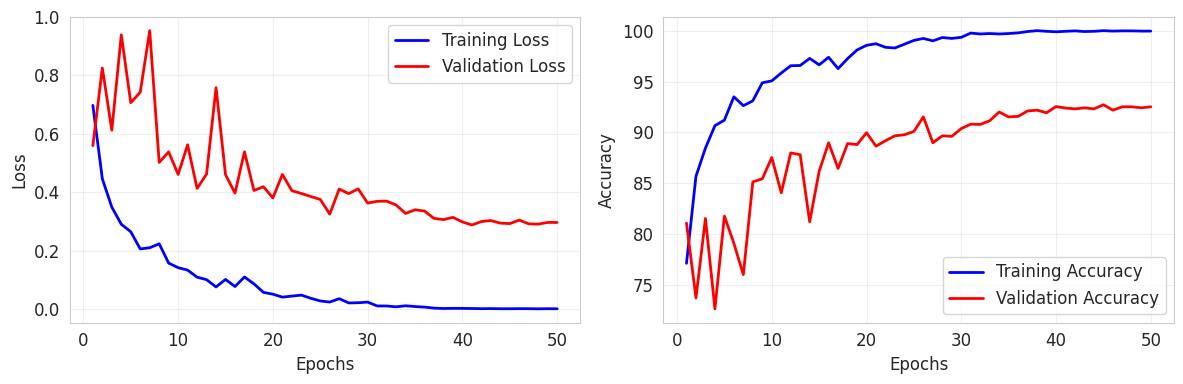


Starting training for data fraction = 50%

Training on 10 classes.
Training samples: 9162.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 11,024,138/11,181,642


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.82it/s]



 Epoch 1/50:
 Train Loss: 0.6033, Train Accuracy: 79.94%
 Val Loss: 0.7195, Val Accuracy: 78.58%
Saved best model (Val Acc: 78.58%).


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.12it/s]



 Epoch 2/50:
 Train Loss: 0.3907, Train Accuracy: 87.13%
 Val Loss: 0.4431, Val Accuracy: 85.99%
Saved best model (Val Acc: 85.99%).


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  6.95it/s]



 Epoch 49/50:
 Train Loss: 0.0029, Train Accuracy: 99.98%
 Val Loss: 0.2554, Val Accuracy: 93.84%


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.30it/s]


 Epoch 50/50:
 Train Loss: 0.0035, Train Accuracy: 99.91%
 Val Loss: 0.2595, Val Accuracy: 93.76%
Training completed in 2725.64 seconds.



 Test Results: 
 Accuracy: 93.33%
 Precision: 93.41%
 Recall: 93.33%
 F1-score: 93.32%


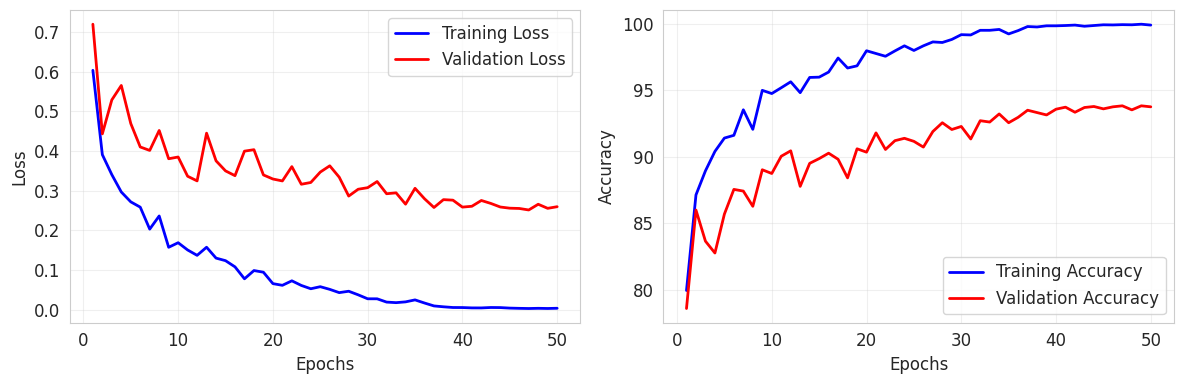


Starting training for data fraction = 75%

Training on 10 classes.
Training samples: 13743.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 11,024,138/11,181,642


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.81it/s]



 Epoch 1/50:
 Train Loss: 0.5345, Train Accuracy: 82.51%
 Val Loss: 0.7378, Val Accuracy: 76.70%
Saved best model (Val Acc: 76.70%).


Validation: 100%|██████████| 62/62 [00:08<00:00,  6.98it/s]



 Epoch 2/50:
 Train Loss: 0.3694, Train Accuracy: 88.07%
 Val Loss: 0.4541, Val Accuracy: 85.59%
Saved best model (Val Acc: 85.59%).


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  7.04it/s]



 Epoch 22/50:
 Train Loss: 0.0736, Train Accuracy: 97.64%
 Val Loss: 0.3240, Val Accuracy: 90.73%


Validation: 100%|██████████| 62/62 [00:08<00:00,  6.94it/s]


 Epoch 23/50:
 Train Loss: 0.0636, Train Accuracy: 97.89%
 Val Loss: 0.3199, Val Accuracy: 91.39%
Early stopping triggered at epoch 23.
Training completed in 1790.63 seconds.



 Test Results: 
 Accuracy: 91.52%
 Precision: 91.82%
 Recall: 91.52%
 F1-score: 91.54%


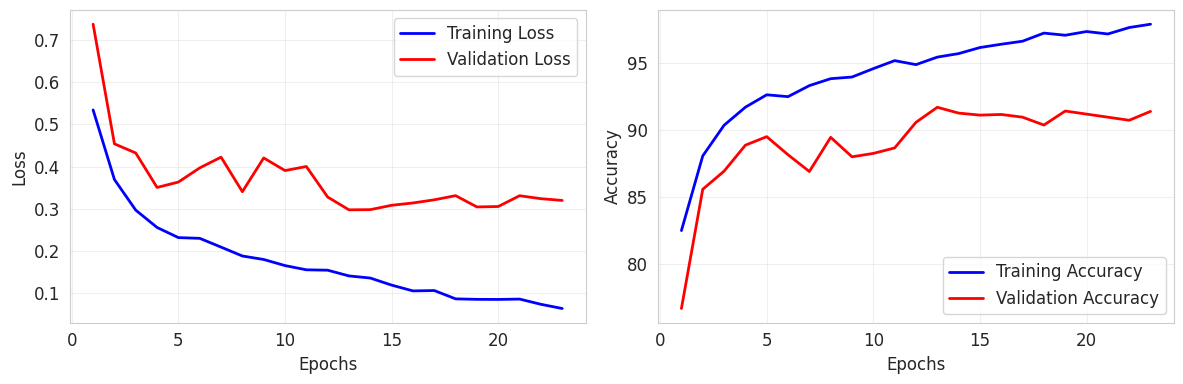


Starting training for data fraction = 100%

Training on 10 classes.
Training samples: 18325.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 11,024,138/11,181,642


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.85it/s]



 Epoch 1/50:
 Train Loss: 0.5247, Train Accuracy: 83.11%
 Val Loss: 0.4539, Val Accuracy: 85.33%
Saved best model (Val Acc: 85.33%).


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.65it/s]



 Epoch 2/50:
 Train Loss: 0.3530, Train Accuracy: 88.70%
 Val Loss: 0.4634, Val Accuracy: 85.97%
Saved best model (Val Acc: 85.97%).


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  6.97it/s]



 Epoch 48/50:
 Train Loss: 0.0033, Train Accuracy: 99.93%
 Val Loss: 0.2088, Val Accuracy: 94.86%


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.25it/s]


 Epoch 49/50:
 Train Loss: 0.0038, Train Accuracy: 99.89%
 Val Loss: 0.2085, Val Accuracy: 94.78%
Early stopping triggered at epoch 49.
Training completed in 4922.43 seconds.



 Test Results: 
 Accuracy: 94.78%
 Precision: 94.81%
 Recall: 94.78%
 F1-score: 94.77%


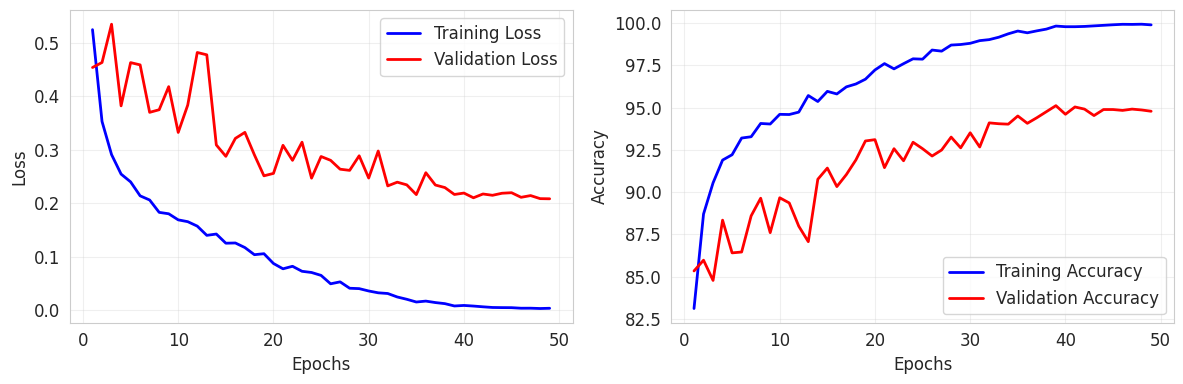


Finished training for all fractions for freeze mode up_to_layer1.


Starting training with freezing mode up_to_layer2


Starting training for data fraction = 10%

Training on 10 classes.
Training samples: 1832.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 10,498,570/11,181,642


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.30it/s]



 Epoch 1/50:
 Train Loss: 0.7299, Train Accuracy: 75.55%
 Val Loss: 1.2663, Val Accuracy: 71.12%
Saved best model (Val Acc: 71.12%).


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.40it/s]



 Epoch 2/50:
 Train Loss: 0.3567, Train Accuracy: 88.70%
 Val Loss: 0.4633, Val Accuracy: 85.38%
Saved best model (Val Acc: 85.38%).


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  7.33it/s]



 Epoch 49/50:
 Train Loss: 0.0014, Train Accuracy: 100.00%
 Val Loss: 0.3470, Val Accuracy: 91.24%


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.48it/s]


 Epoch 50/50:
 Train Loss: 0.0013, Train Accuracy: 99.95%
 Val Loss: 0.3499, Val Accuracy: 91.32%
Training completed in 876.22 seconds.



 Test Results: 
 Accuracy: 91.21%
 Precision: 91.45%
 Recall: 91.21%
 F1-score: 91.20%


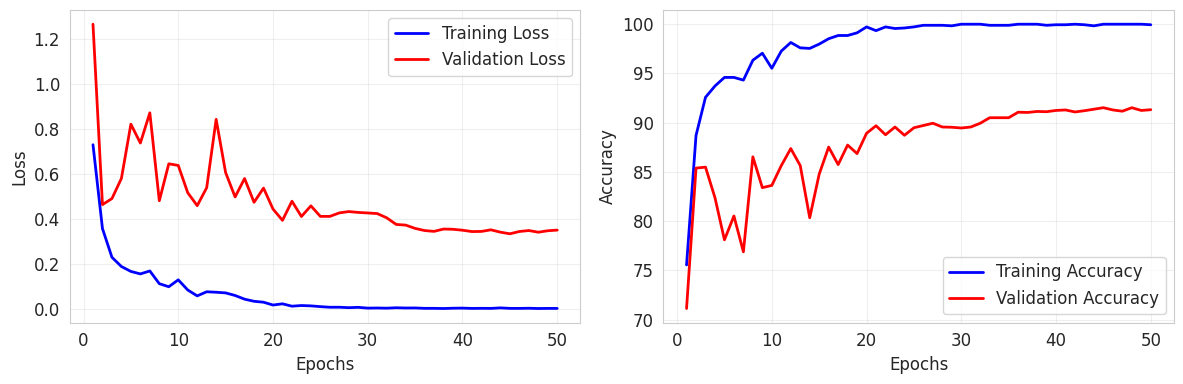


Starting training for data fraction = 25%

Training on 10 classes.
Training samples: 4581.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 10,498,570/11,181,642


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.01it/s]



 Epoch 1/50:
 Train Loss: 0.6448, Train Accuracy: 78.11%
 Val Loss: 0.4677, Val Accuracy: 85.23%
Saved best model (Val Acc: 85.23%).


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.87it/s]



 Epoch 2/50:
 Train Loss: 0.3565, Train Accuracy: 88.34%
 Val Loss: 0.4378, Val Accuracy: 86.50%
Saved best model (Val Acc: 86.50%).


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  7.34it/s]



 Epoch 49/50:
 Train Loss: 0.0022, Train Accuracy: 99.96%
 Val Loss: 0.2937, Val Accuracy: 93.00%


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.07it/s]


 Epoch 50/50:
 Train Loss: 0.0022, Train Accuracy: 99.91%
 Val Loss: 0.2928, Val Accuracy: 93.33%
Saved best model (Val Acc: 93.33%).
Training completed in 1569.71 seconds.



 Test Results: 
 Accuracy: 93.61%
 Precision: 93.65%
 Recall: 93.61%
 F1-score: 93.59%


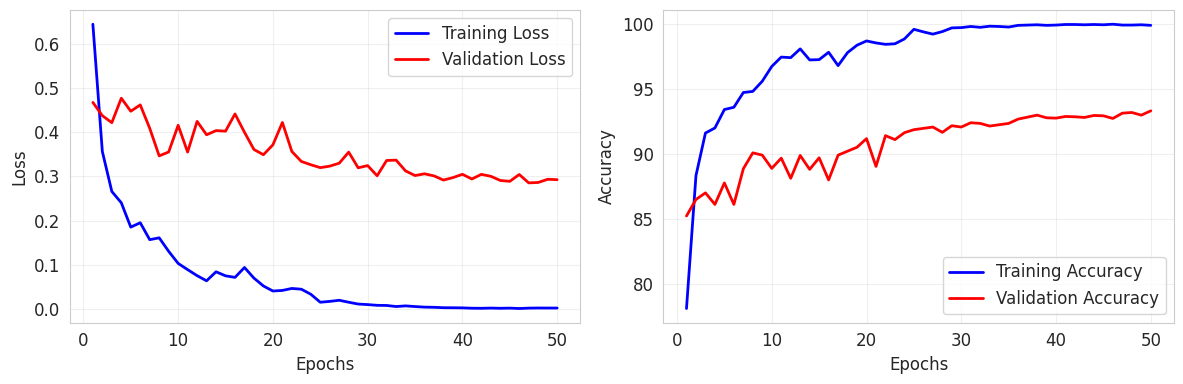


Starting training for data fraction = 50%

Training on 10 classes.
Training samples: 9162.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 10,498,570/11,181,642


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.31it/s]



 Epoch 1/50:
 Train Loss: 0.5118, Train Accuracy: 83.10%
 Val Loss: 0.3858, Val Accuracy: 87.57%
Saved best model (Val Acc: 87.57%).


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.20it/s]



 Epoch 2/50:
 Train Loss: 0.3187, Train Accuracy: 89.58%
 Val Loss: 0.3825, Val Accuracy: 88.49%
Saved best model (Val Acc: 88.49%).


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  7.06it/s]



 Epoch 48/50:
 Train Loss: 0.0038, Train Accuracy: 99.88%
 Val Loss: 0.2415, Val Accuracy: 94.30%


Validation: 100%|██████████| 62/62 [00:08<00:00,  6.90it/s]


 Epoch 49/50:
 Train Loss: 0.0056, Train Accuracy: 99.93%
 Val Loss: 0.2338, Val Accuracy: 94.37%
Early stopping triggered at epoch 49.
Training completed in 2634.34 seconds.



 Test Results: 
 Accuracy: 94.53%
 Precision: 94.58%
 Recall: 94.53%
 F1-score: 94.52%


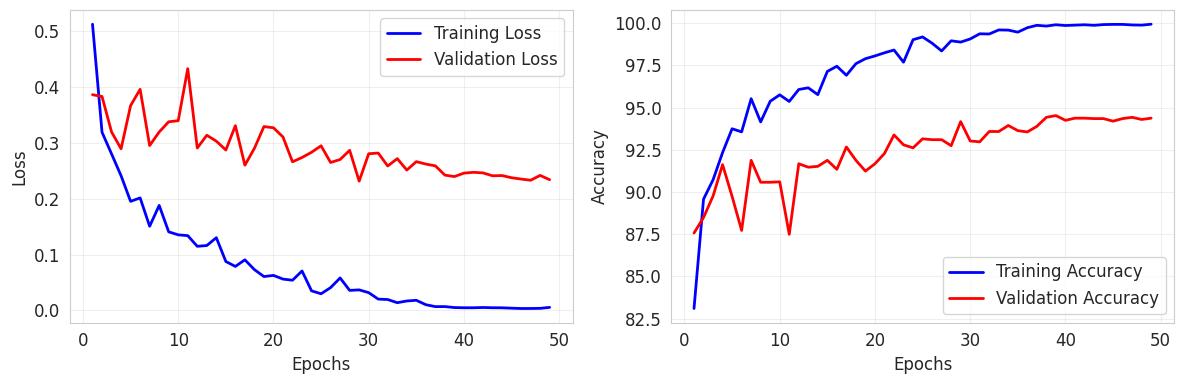


Starting training for data fraction = 75%

Training on 10 classes.
Training samples: 13743.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 10,498,570/11,181,642


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.76it/s]



 Epoch 1/50:
 Train Loss: 0.4681, Train Accuracy: 84.78%
 Val Loss: 0.5876, Val Accuracy: 82.94%
Saved best model (Val Acc: 82.94%).


Validation: 100%|██████████| 62/62 [00:08<00:00,  6.97it/s]



 Epoch 2/50:
 Train Loss: 0.3056, Train Accuracy: 90.38%
 Val Loss: 0.4035, Val Accuracy: 87.19%
Saved best model (Val Acc: 87.19%).


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  6.95it/s]



 Epoch 22/50:
 Train Loss: 0.0536, Train Accuracy: 98.38%
 Val Loss: 0.3014, Val Accuracy: 92.23%


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.89it/s]


 Epoch 23/50:
 Train Loss: 0.0567, Train Accuracy: 98.18%
 Val Loss: 0.2733, Val Accuracy: 92.59%
Early stopping triggered at epoch 23.
Training completed in 1798.79 seconds.



 Test Results: 
 Accuracy: 92.49%
 Precision: 92.67%
 Recall: 92.49%
 F1-score: 92.50%


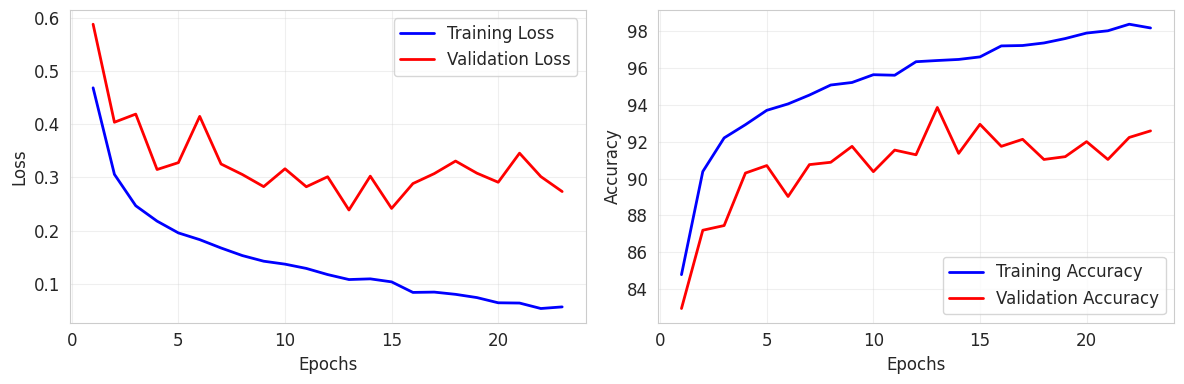


Starting training for data fraction = 100%

Training on 10 classes.
Training samples: 18325.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 10,498,570/11,181,642


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.87it/s]



 Epoch 1/50:
 Train Loss: 0.4399, Train Accuracy: 85.93%
 Val Loss: 0.5284, Val Accuracy: 83.75%
Saved best model (Val Acc: 83.75%).


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.79it/s]



 Epoch 2/50:
 Train Loss: 0.2919, Train Accuracy: 90.65%
 Val Loss: 0.4075, Val Accuracy: 88.34%
Saved best model (Val Acc: 88.34%).


...

Validation: 100%|██████████| 62/62 [00:09<00:00,  6.76it/s]



 Epoch 49/50:
 Train Loss: 0.0040, Train Accuracy: 99.91%
 Val Loss: 0.1828, Val Accuracy: 96.05%
Saved best model (Val Acc: 96.05%).


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.81it/s]


 Epoch 50/50:
 Train Loss: 0.0043, Train Accuracy: 99.89%
 Val Loss: 0.1819, Val Accuracy: 95.85%
Training completed in 5049.90 seconds.



 Test Results: 
 Accuracy: 95.29%
 Precision: 95.32%
 Recall: 95.29%
 F1-score: 95.28%


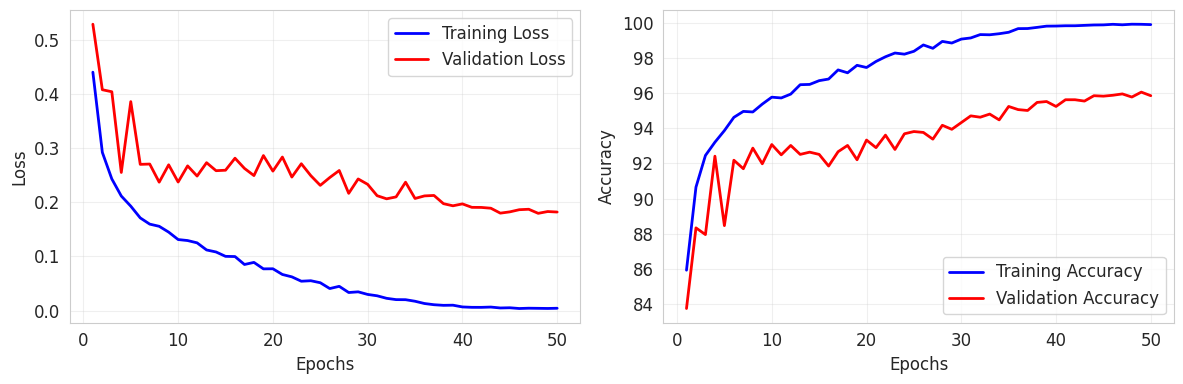


Finished training for all fractions for freeze mode up_to_layer2.


Starting training with freezing mode up_to_layer3


Starting training for data fraction = 10%

Training on 10 classes.
Training samples: 1832.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 8,398,858/11,181,642


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.58it/s]



 Epoch 1/50:
 Train Loss: 0.5974, Train Accuracy: 80.68%
 Val Loss: 0.4948, Val Accuracy: 86.66%
Saved best model (Val Acc: 86.66%).


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.82it/s]



 Epoch 2/50:
 Train Loss: 0.2331, Train Accuracy: 92.14%
 Val Loss: 0.3240, Val Accuracy: 90.12%
Saved best model (Val Acc: 90.12%).


...

Validation: 100%|██████████| 62/62 [00:09<00:00,  6.82it/s]



 Epoch 25/50:
 Train Loss: 0.0196, Train Accuracy: 99.51%
 Val Loss: 0.3194, Val Accuracy: 92.06%


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.88it/s]


 Epoch 26/50:
 Train Loss: 0.0154, Train Accuracy: 99.40%
 Val Loss: 0.3204, Val Accuracy: 91.77%
Early stopping triggered at epoch 26.
Training completed in 483.28 seconds.



 Test Results: 
 Accuracy: 91.80%
 Precision: 92.01%
 Recall: 91.80%
 F1-score: 91.80%


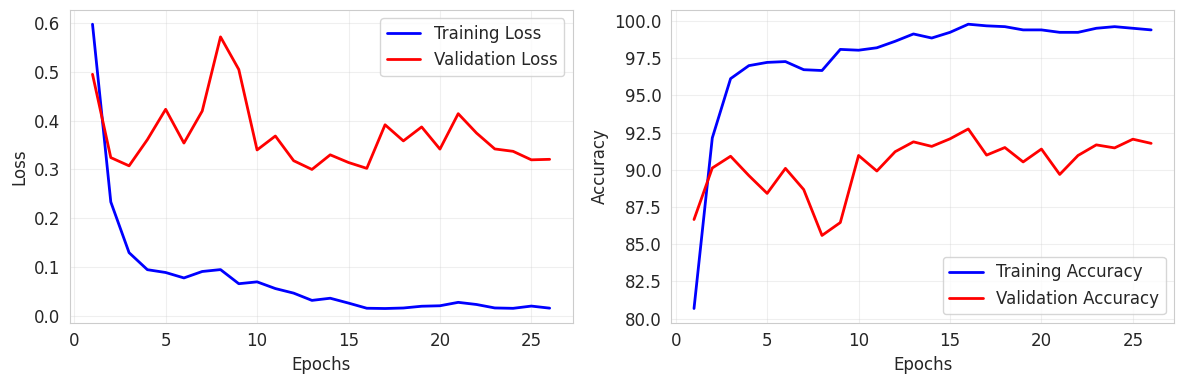


Starting training for data fraction = 25%

Training on 10 classes.
Training samples: 4581.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 8,398,858/11,181,642


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.68it/s]



 Epoch 1/50:
 Train Loss: 0.4878, Train Accuracy: 83.98%
 Val Loss: 0.2688, Val Accuracy: 91.42%
Saved best model (Val Acc: 91.42%).


Validation: 100%|██████████| 62/62 [00:08<00:00,  6.97it/s]



 Epoch 2/50:
 Train Loss: 0.2494, Train Accuracy: 92.10%
 Val Loss: 0.2851, Val Accuracy: 91.06%


...

Validation: 100%|██████████| 62/62 [00:09<00:00,  6.77it/s]



 Epoch 49/50:
 Train Loss: 0.0013, Train Accuracy: 100.00%
 Val Loss: 0.2089, Val Accuracy: 95.31%


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.79it/s]


 Epoch 50/50:
 Train Loss: 0.0017, Train Accuracy: 99.98%
 Val Loss: 0.2063, Val Accuracy: 95.34%
Training completed in 1616.96 seconds.



 Test Results: 
 Accuracy: 95.42%
 Precision: 95.42%
 Recall: 95.42%
 F1-score: 95.41%


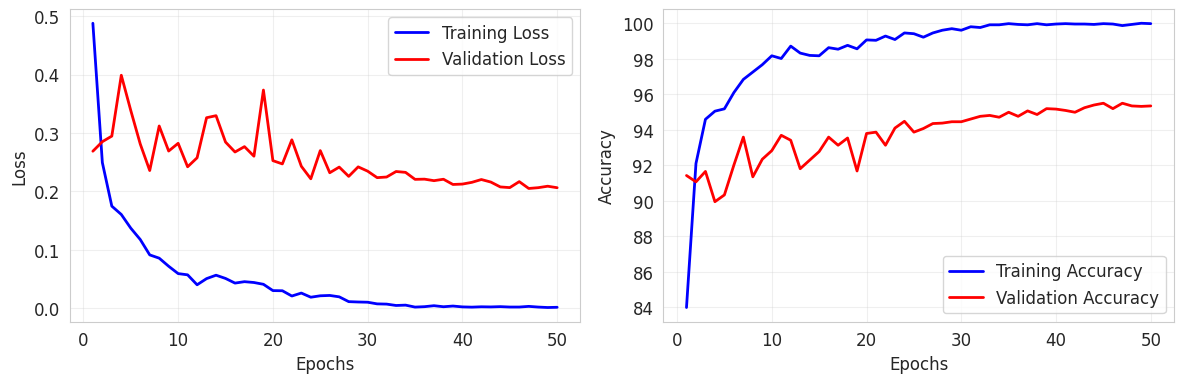


Starting training for data fraction = 50%

Training on 10 classes.
Training samples: 9162.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 8,398,858/11,181,642


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.55it/s]



 Epoch 1/50:
 Train Loss: 0.4007, Train Accuracy: 86.95%
 Val Loss: 0.3300, Val Accuracy: 89.51%
Saved best model (Val Acc: 89.51%).


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.62it/s]



 Epoch 2/50:
 Train Loss: 0.2216, Train Accuracy: 92.67%
 Val Loss: 0.2453, Val Accuracy: 92.69%
Saved best model (Val Acc: 92.69%).


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  7.22it/s]



 Epoch 26/50:
 Train Loss: 0.0320, Train Accuracy: 98.94%
 Val Loss: 0.1986, Val Accuracy: 94.93%


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.41it/s]


 Epoch 27/50:
 Train Loss: 0.0209, Train Accuracy: 99.50%
 Val Loss: 0.2035, Val Accuracy: 95.01%
Early stopping triggered at epoch 27.
Training completed in 1477.72 seconds.



 Test Results: 
 Accuracy: 95.09%
 Precision: 95.14%
 Recall: 95.09%
 F1-score: 95.08%


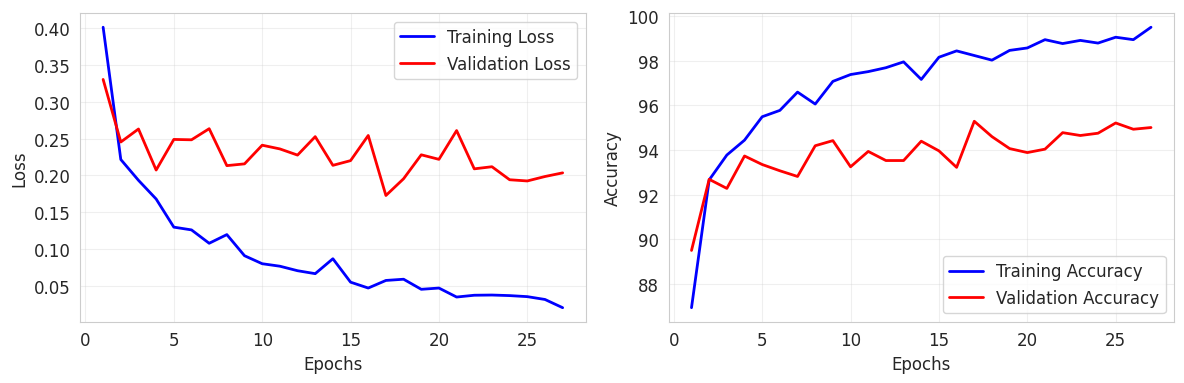


Starting training for data fraction = 75%

Training on 10 classes.
Training samples: 13743.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 8,398,858/11,181,642


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.06it/s]



 Epoch 1/50:
 Train Loss: 0.3497, Train Accuracy: 88.48%
 Val Loss: 0.2788, Val Accuracy: 91.11%
Saved best model (Val Acc: 91.11%).


Validation: 100%|██████████| 62/62 [00:08<00:00,  6.90it/s]



 Epoch 2/50:
 Train Loss: 0.2157, Train Accuracy: 92.99%
 Val Loss: 0.2929, Val Accuracy: 90.76%


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  6.96it/s]



 Epoch 49/50:
 Train Loss: 0.0035, Train Accuracy: 99.93%
 Val Loss: 0.1574, Val Accuracy: 96.41%
Saved best model (Val Acc: 96.41%).


Validation: 100%|██████████| 62/62 [00:08<00:00,  6.90it/s]


 Epoch 50/50:
 Train Loss: 0.0029, Train Accuracy: 99.93%
 Val Loss: 0.1592, Val Accuracy: 96.38%
Training completed in 3887.97 seconds.



 Test Results: 
 Accuracy: 96.41%
 Precision: 96.43%
 Recall: 96.41%
 F1-score: 96.41%


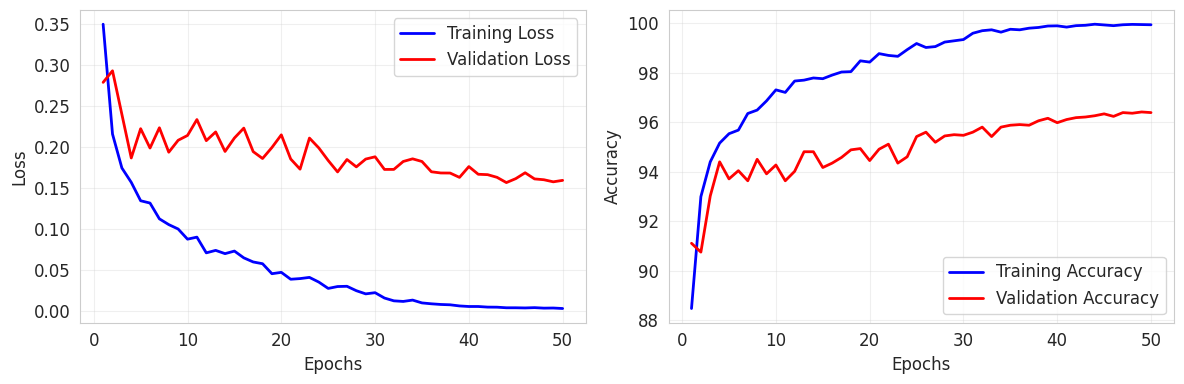


Starting training for data fraction = 100%

Training on 10 classes.
Training samples: 18325.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 8,398,858/11,181,642


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.68it/s]



 Epoch 1/50:
 Train Loss: 0.3382, Train Accuracy: 88.96%
 Val Loss: 0.2205, Val Accuracy: 93.15%
Saved best model (Val Acc: 93.15%).


Validation: 100%|██████████| 62/62 [00:09<00:00,  6.72it/s]



 Epoch 2/50:
 Train Loss: 0.2061, Train Accuracy: 93.37%
 Val Loss: 0.2252, Val Accuracy: 93.30%
Saved best model (Val Acc: 93.30%).


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  7.23it/s]



 Epoch 49/50:
 Train Loss: 0.0049, Train Accuracy: 99.85%
 Val Loss: 0.1438, Val Accuracy: 96.84%


Validation: 100%|██████████| 62/62 [00:08<00:00,  6.99it/s]


 Epoch 50/50:
 Train Loss: 0.0043, Train Accuracy: 99.89%
 Val Loss: 0.1424, Val Accuracy: 96.84%
Training completed in 4985.13 seconds.



 Test Results: 
 Accuracy: 96.36%
 Precision: 96.38%
 Recall: 96.36%
 F1-score: 96.36%


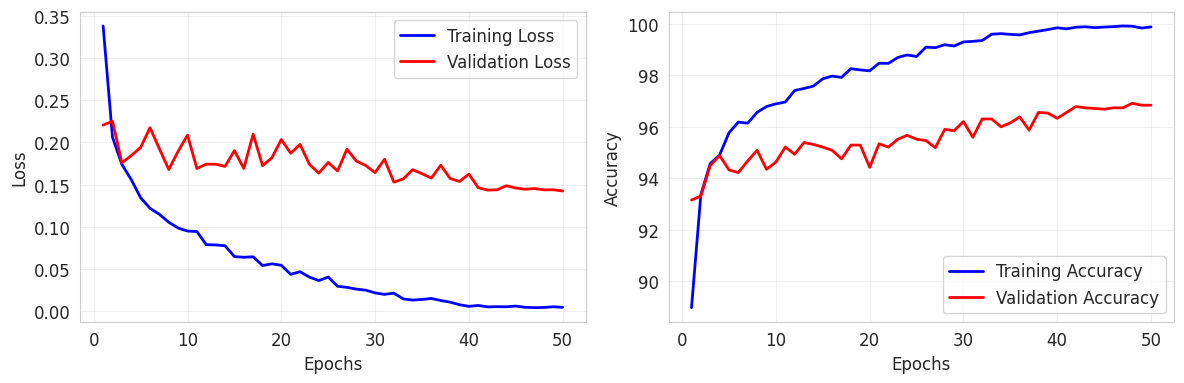


Finished training for all fractions for freeze mode up_to_layer3.


Finished training for all fractions for all freezing modes.



In [7]:
# Task 2: Fine-tune a pretrained ResNet model
all_results = []

freeze_modes = Config.FREEZE_LAYERS

for freeze_mode in freeze_modes:
  print(f"\nStarting training with freezing mode {freeze_mode}\n")

  for frac in data_fractions:
    print(f"\nStarting training for data fraction = {frac*100:.0f}%\n")

    train_loader, val_loader, test_loader, num_classes = get_data_loaders(
        data_path=str(Config.DATA_PATH),
        batch_size=Config.BATCH_SIZE,
        num_workers=Config.NUM_WORKERS,
        train_split=Config.TRAIN_SPLIT,
        val_split=Config.VAL_SPLIT,
        test_split=Config.TEST_SPLIT,
        use_augmentation=Config.USE_AUGMENTATION,
        random_seed=Config.RANDOM_SEED,
        data_fraction=frac,
        fixed_indices=fixed,
        save_processed_root=str(Config.PROCESSED_DIR),
    )

    result = fine_tune_pretrained(
        config=Config,
        data_fraction=frac,
        save_mode=True,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        freeze_mode=freeze_mode
    )

    all_results.append(result)

  print(f"\nFinished training for all fractions for freeze mode {freeze_mode}.\n")

print("\nFinished training for all fractions for all freezing modes.\n")

In [8]:
# Save combined summary JSON
summary_path = Config.METRICS_DIR / "task2_finetune_summary.json"

with open(summary_path, "w") as f:
    json.dump(all_results, f, indent=4)

print(f"Saved combined summary to {summary_path}")

Saved combined summary to /content/TOL506M_Final_Project/results/metrics/task2_finetune_summary.json



Learning curves of freeze mode all_but_fc and for fraction 10%


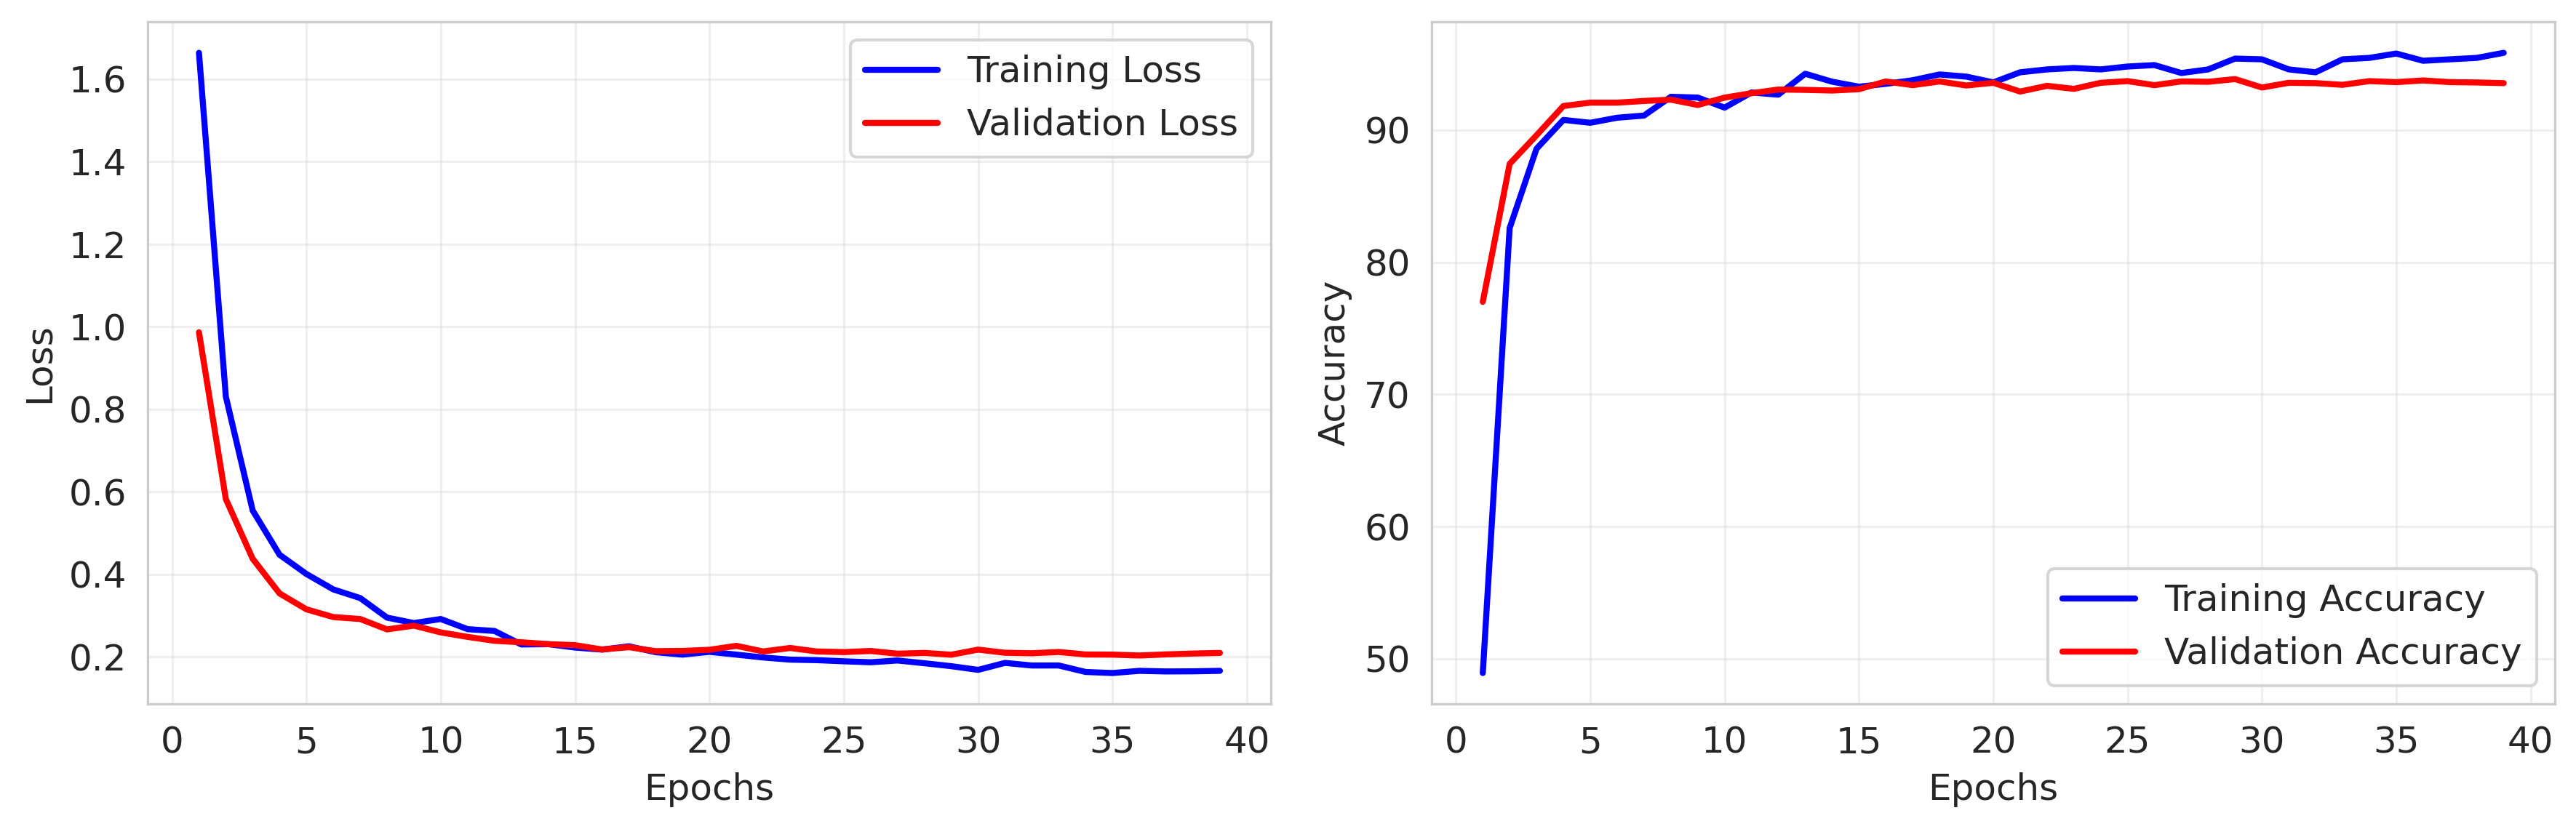


Learning curves of freeze mode all_but_fc and for fraction 25%


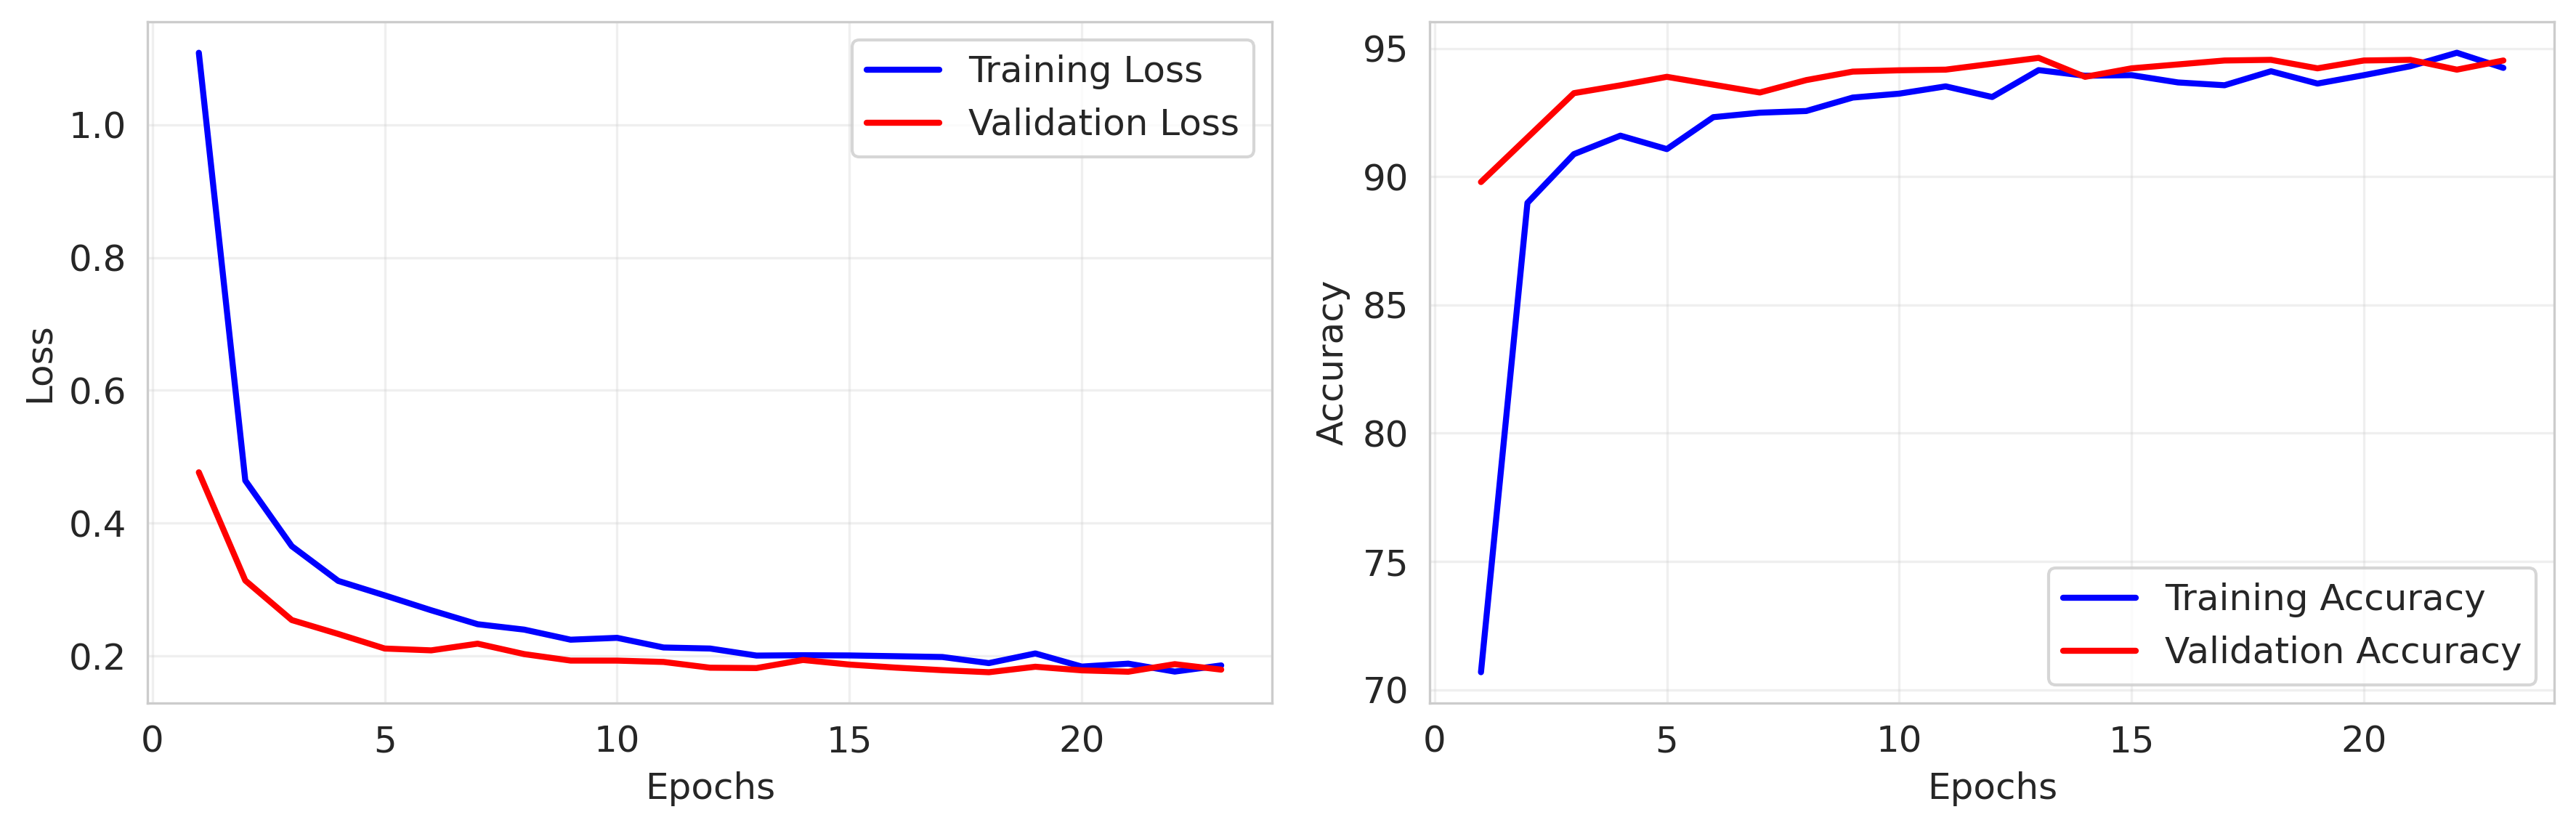


Learning curves of freeze mode all_but_fc and for fraction 50%


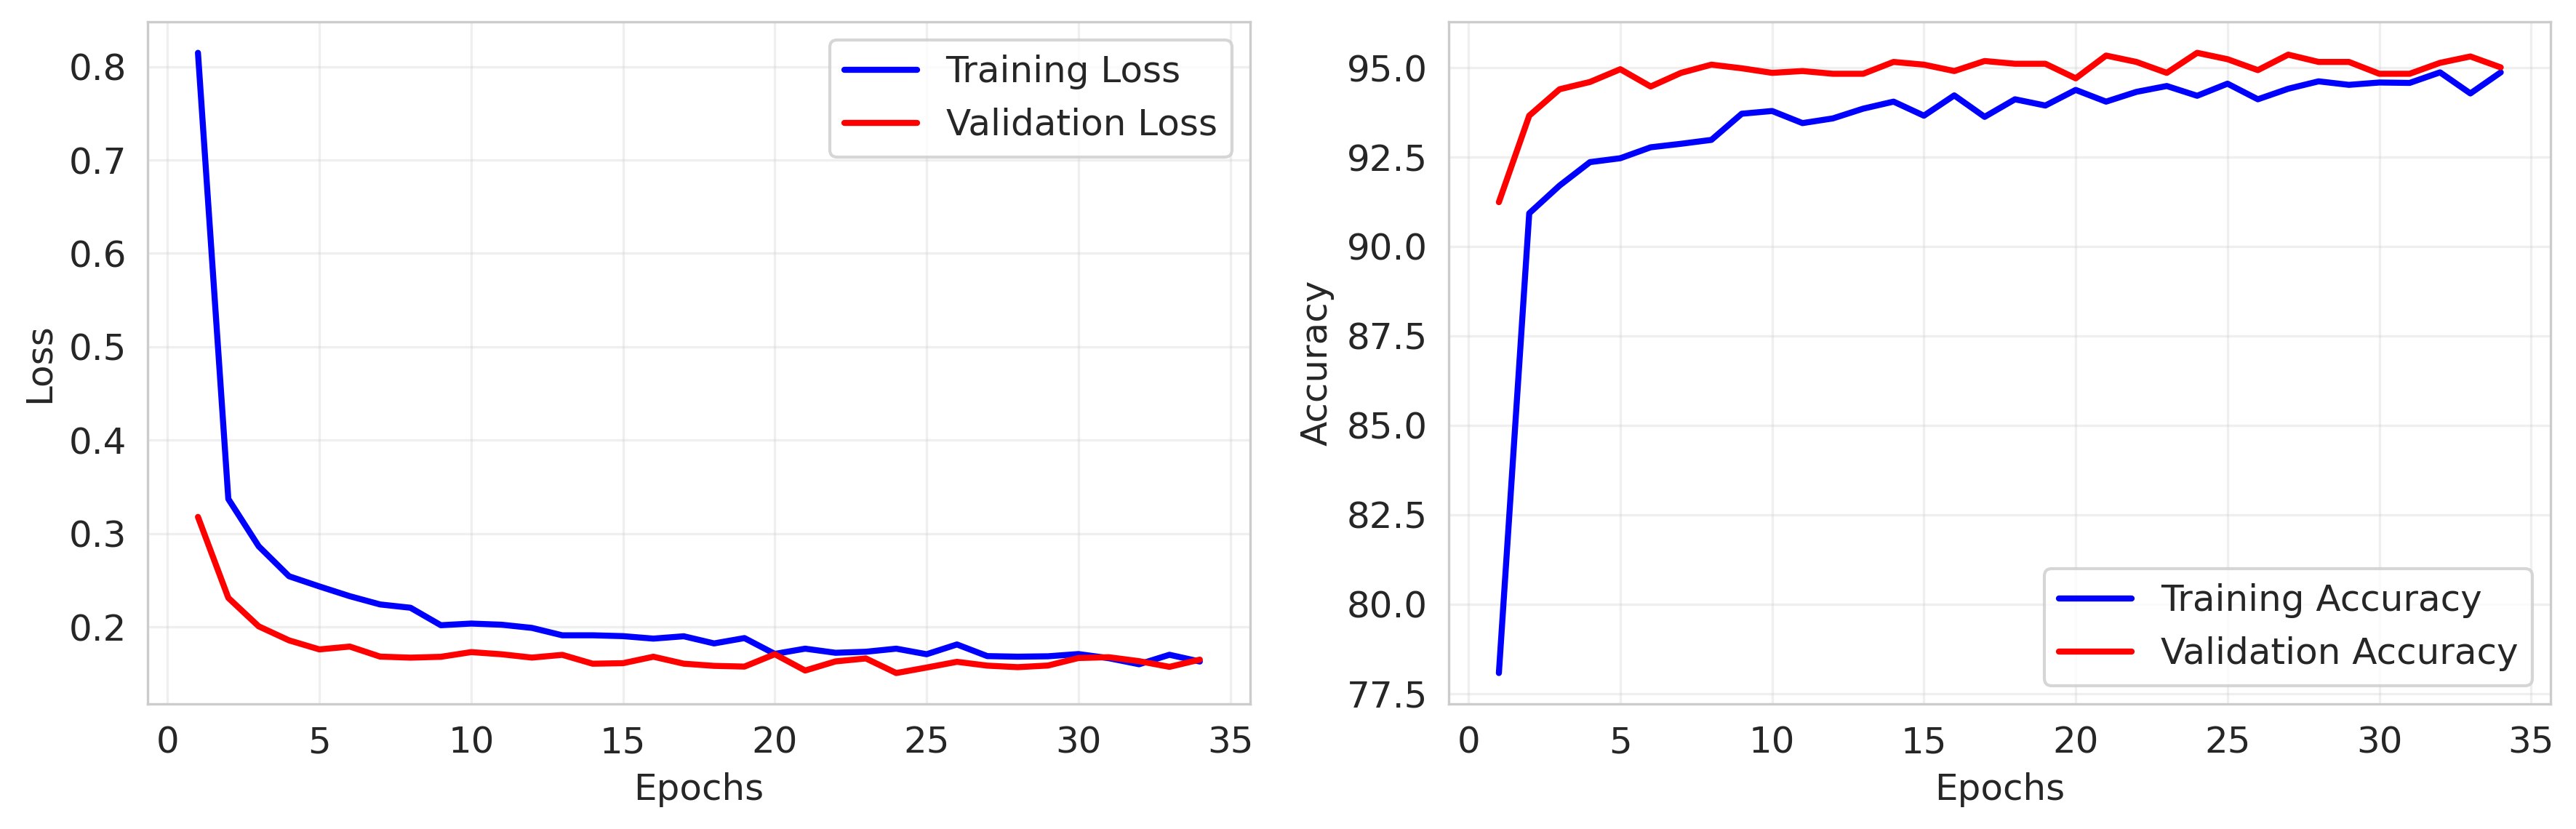


Learning curves of freeze mode all_but_fc and for fraction 75%


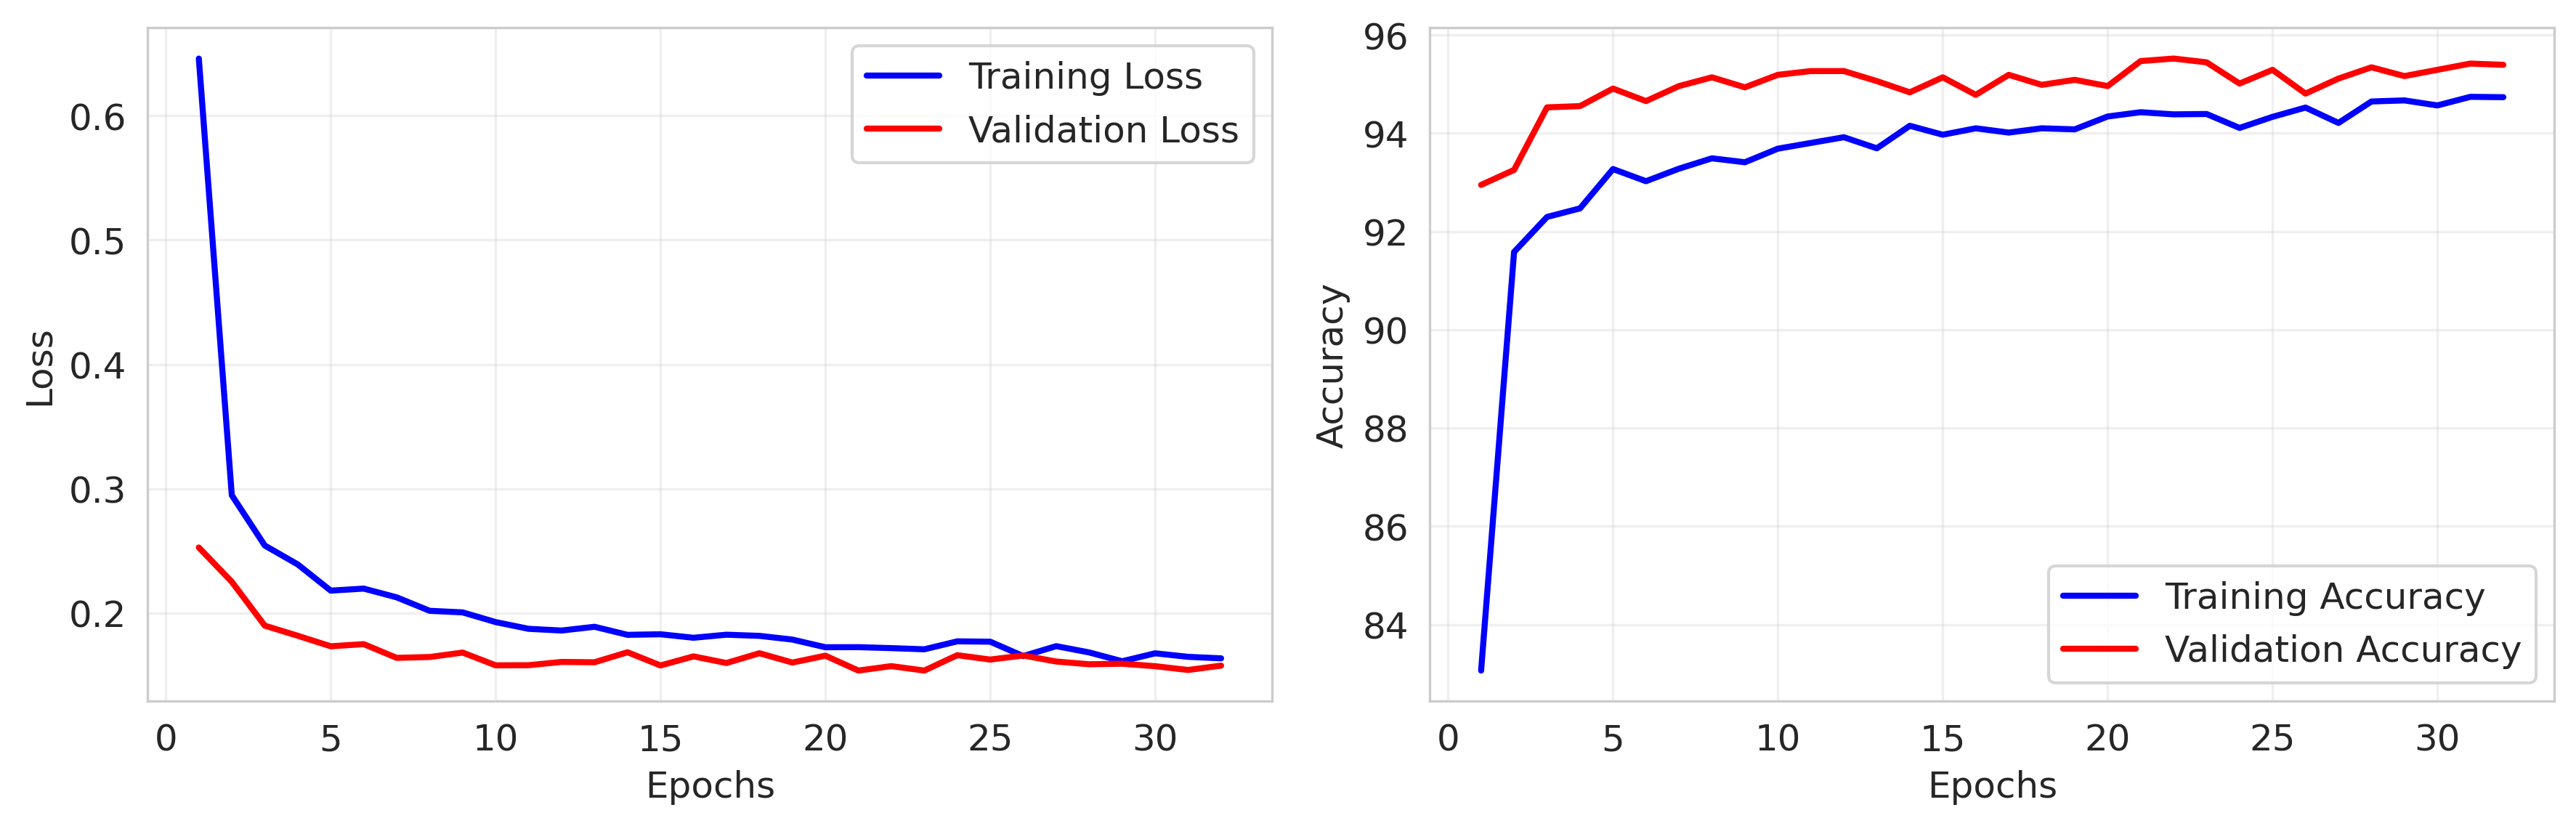


Learning curves of freeze mode all_but_fc and for fraction 100%


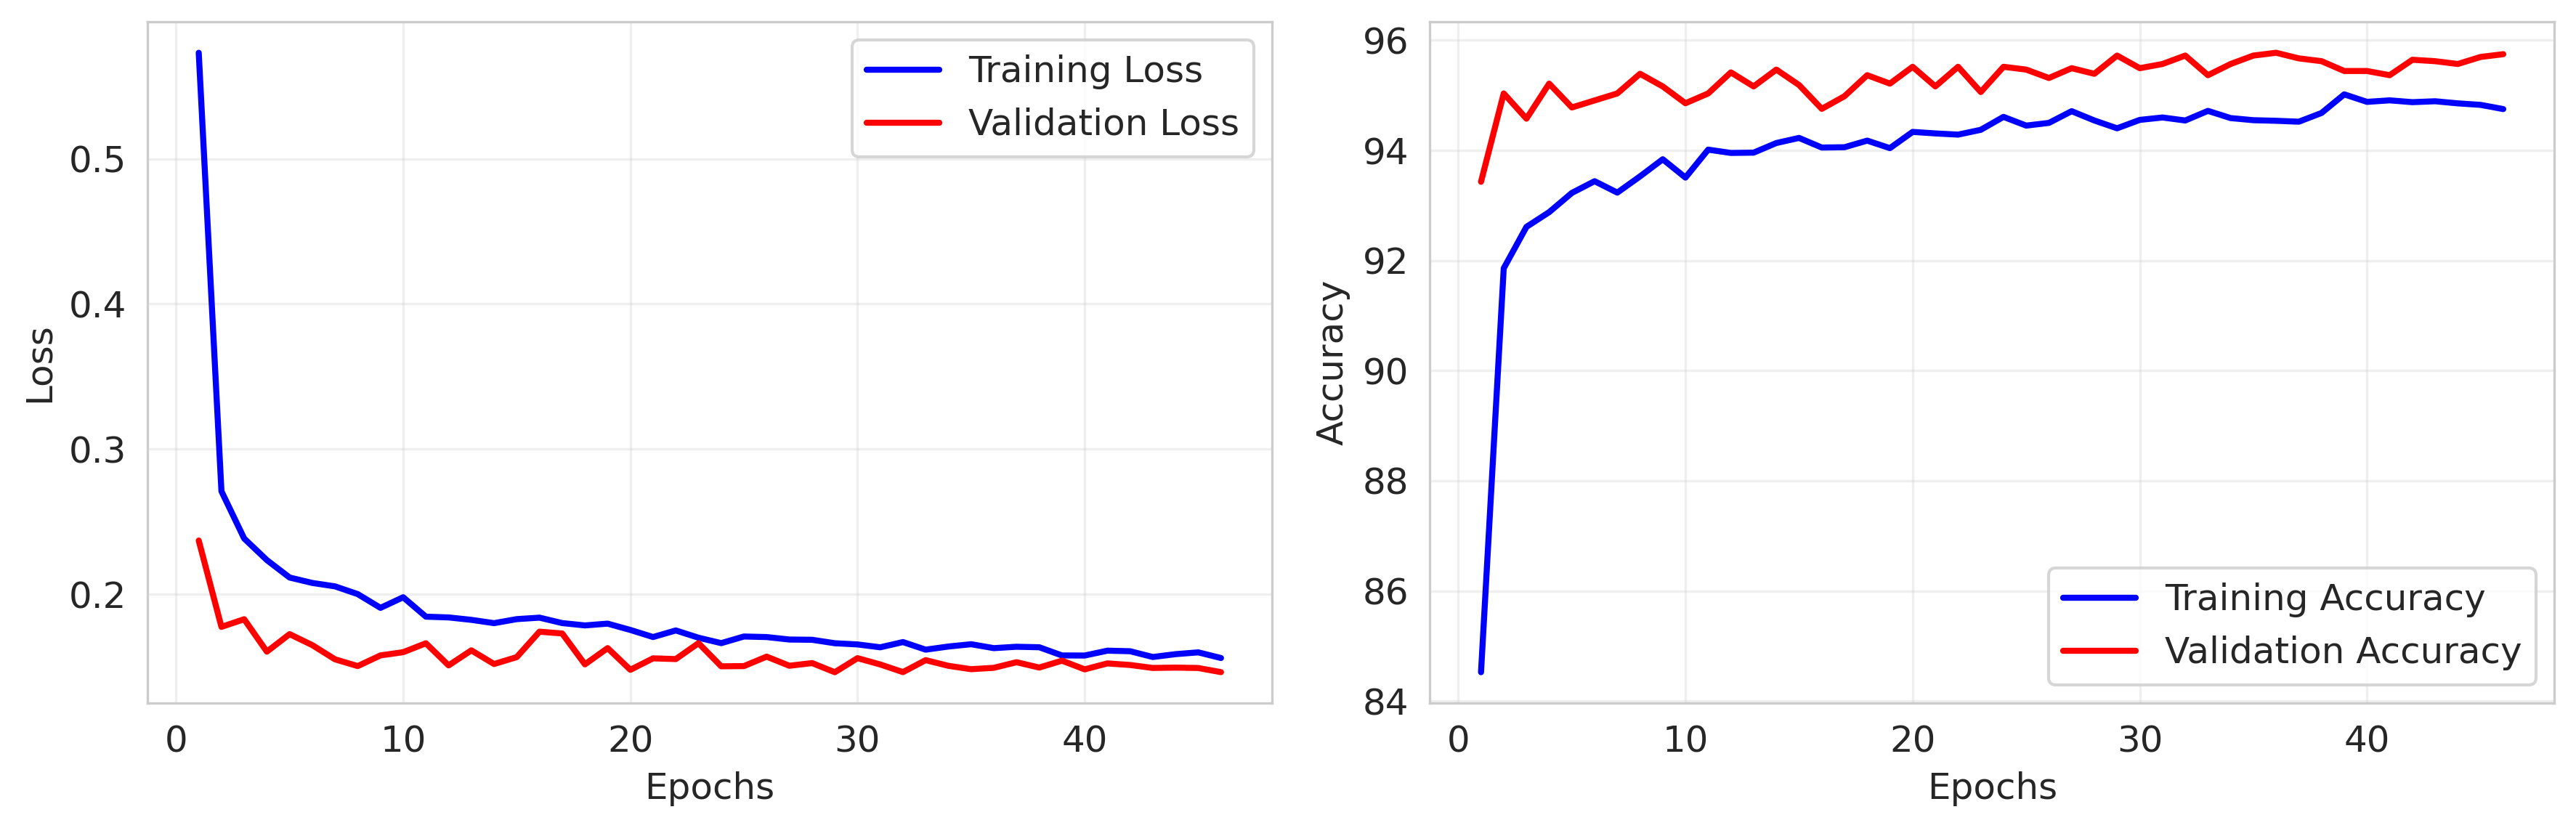


Learning curves of freeze mode up_to_layer1 and for fraction 10%


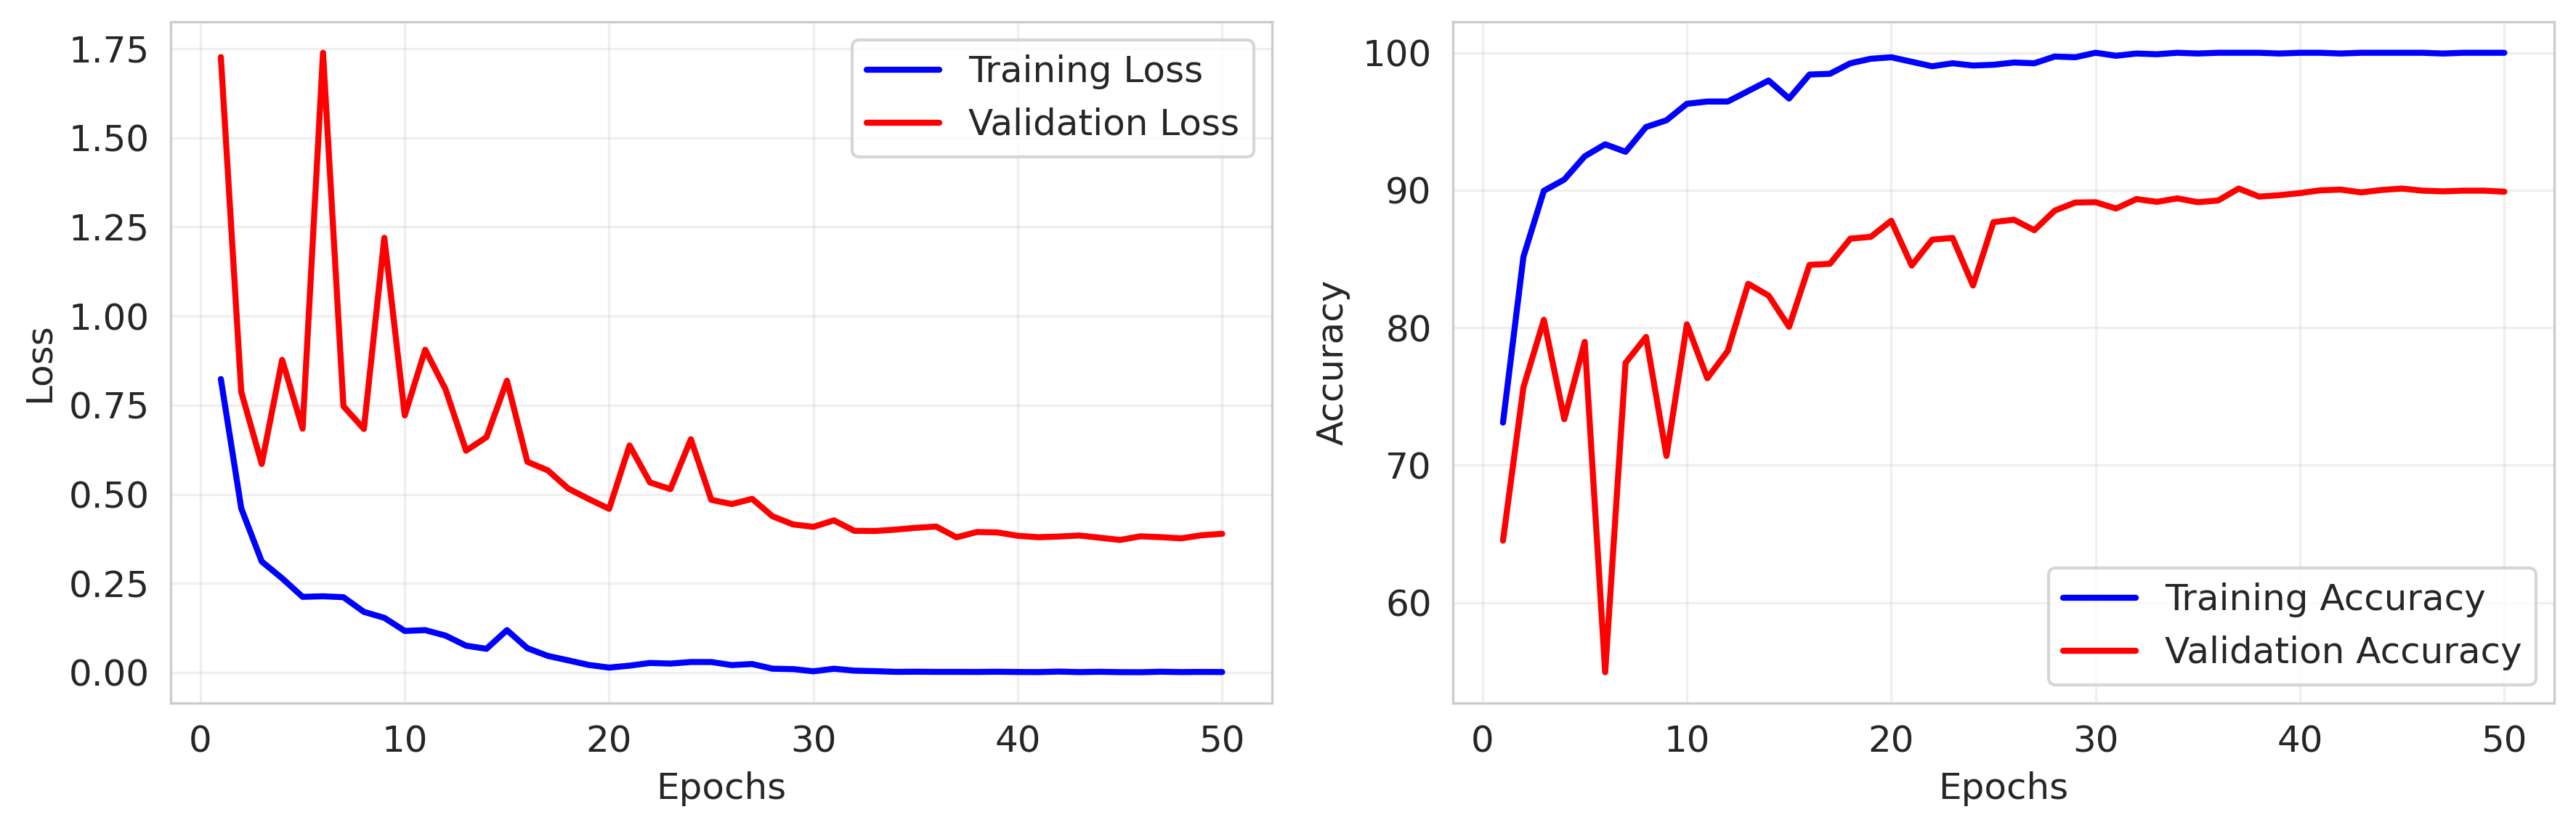


Learning curves of freeze mode up_to_layer1 and for fraction 25%


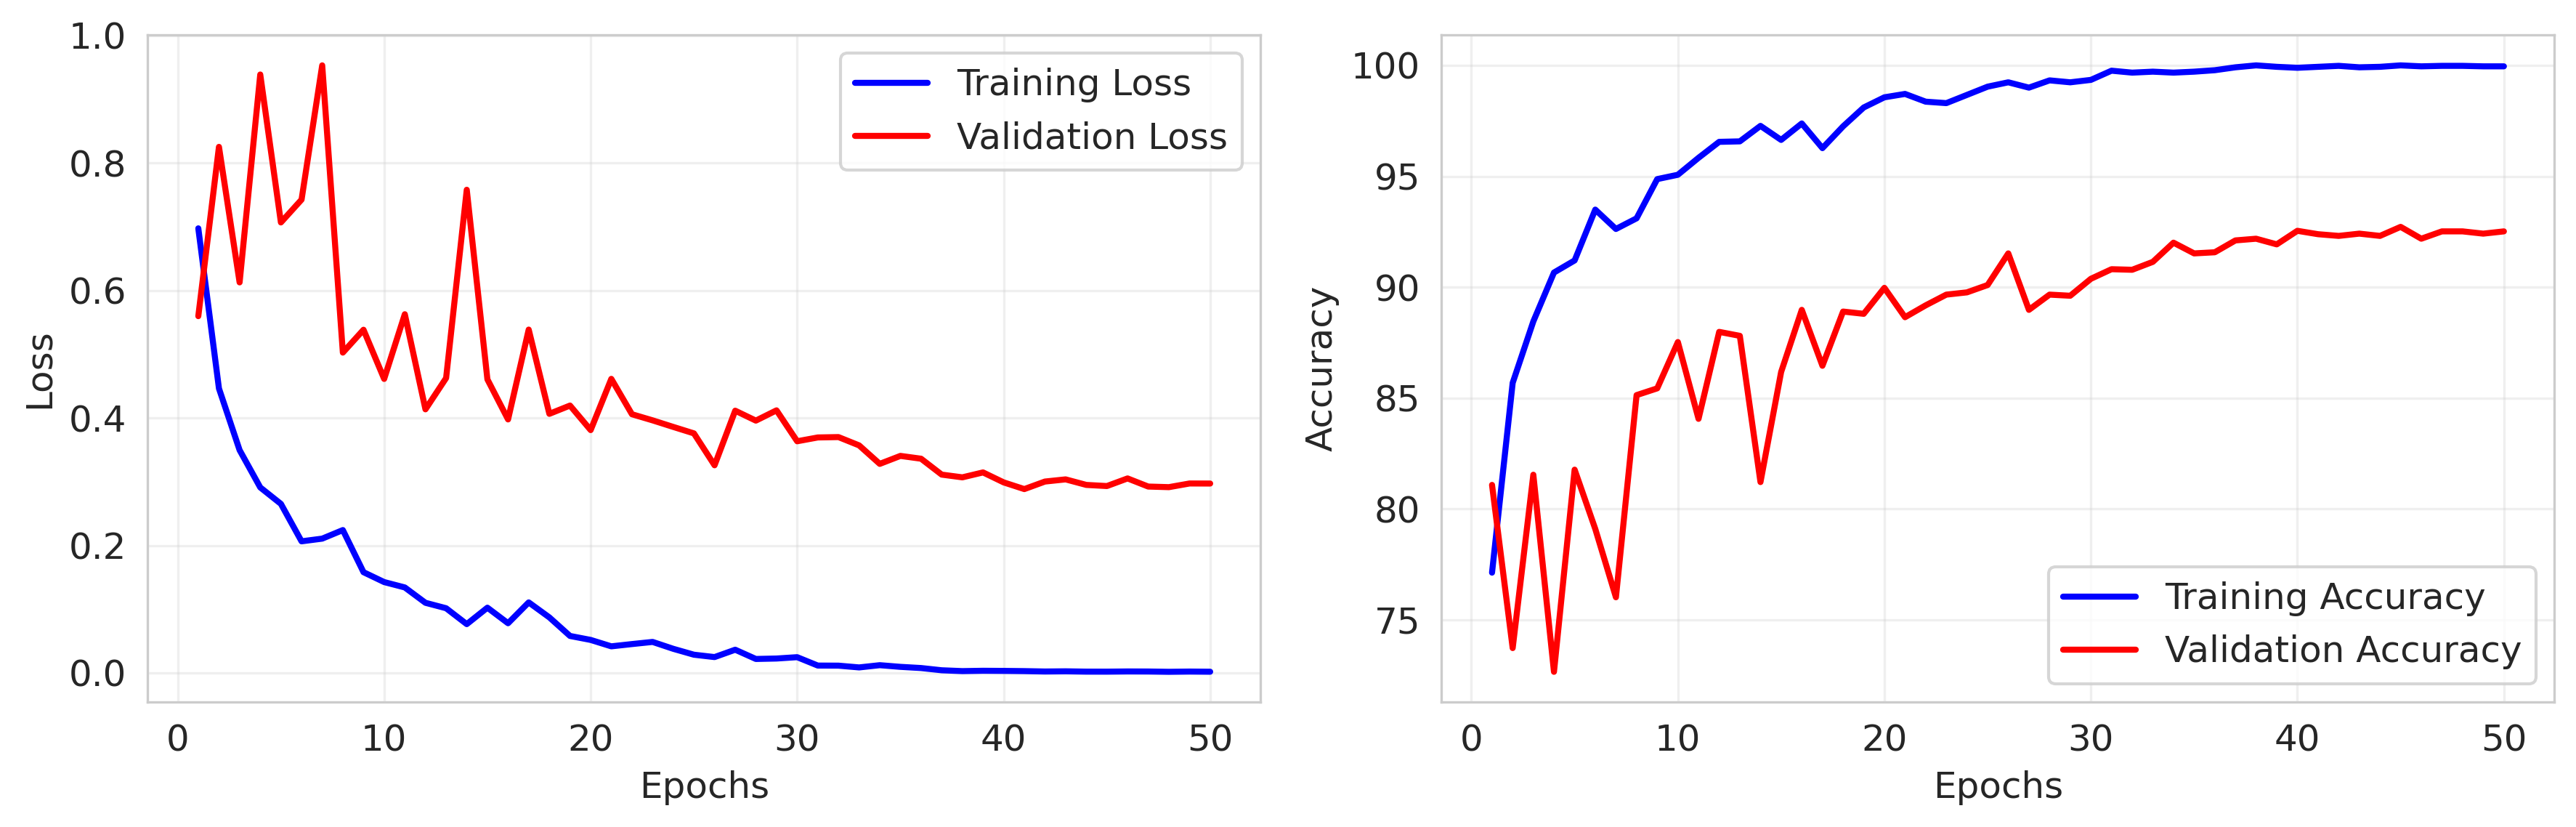


Learning curves of freeze mode up_to_layer1 and for fraction 50%


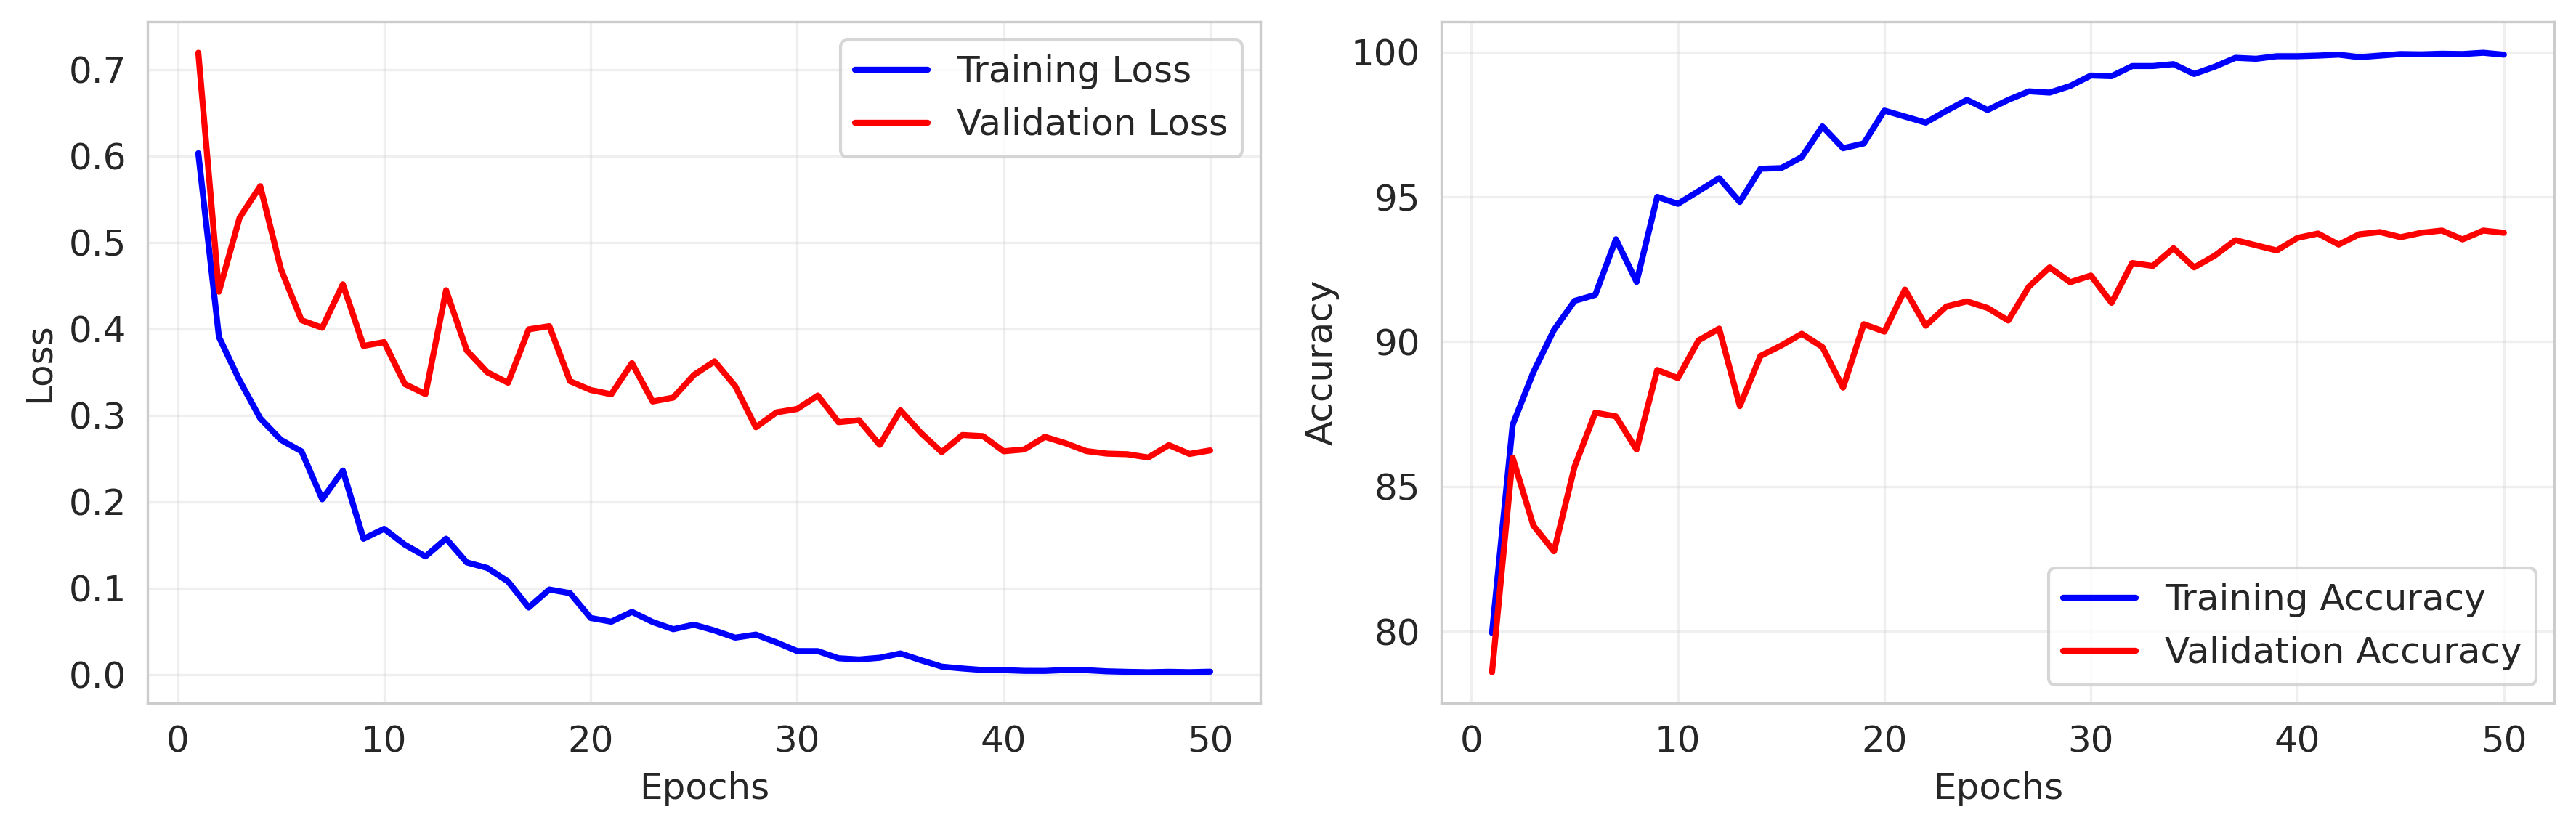


Learning curves of freeze mode up_to_layer1 and for fraction 75%


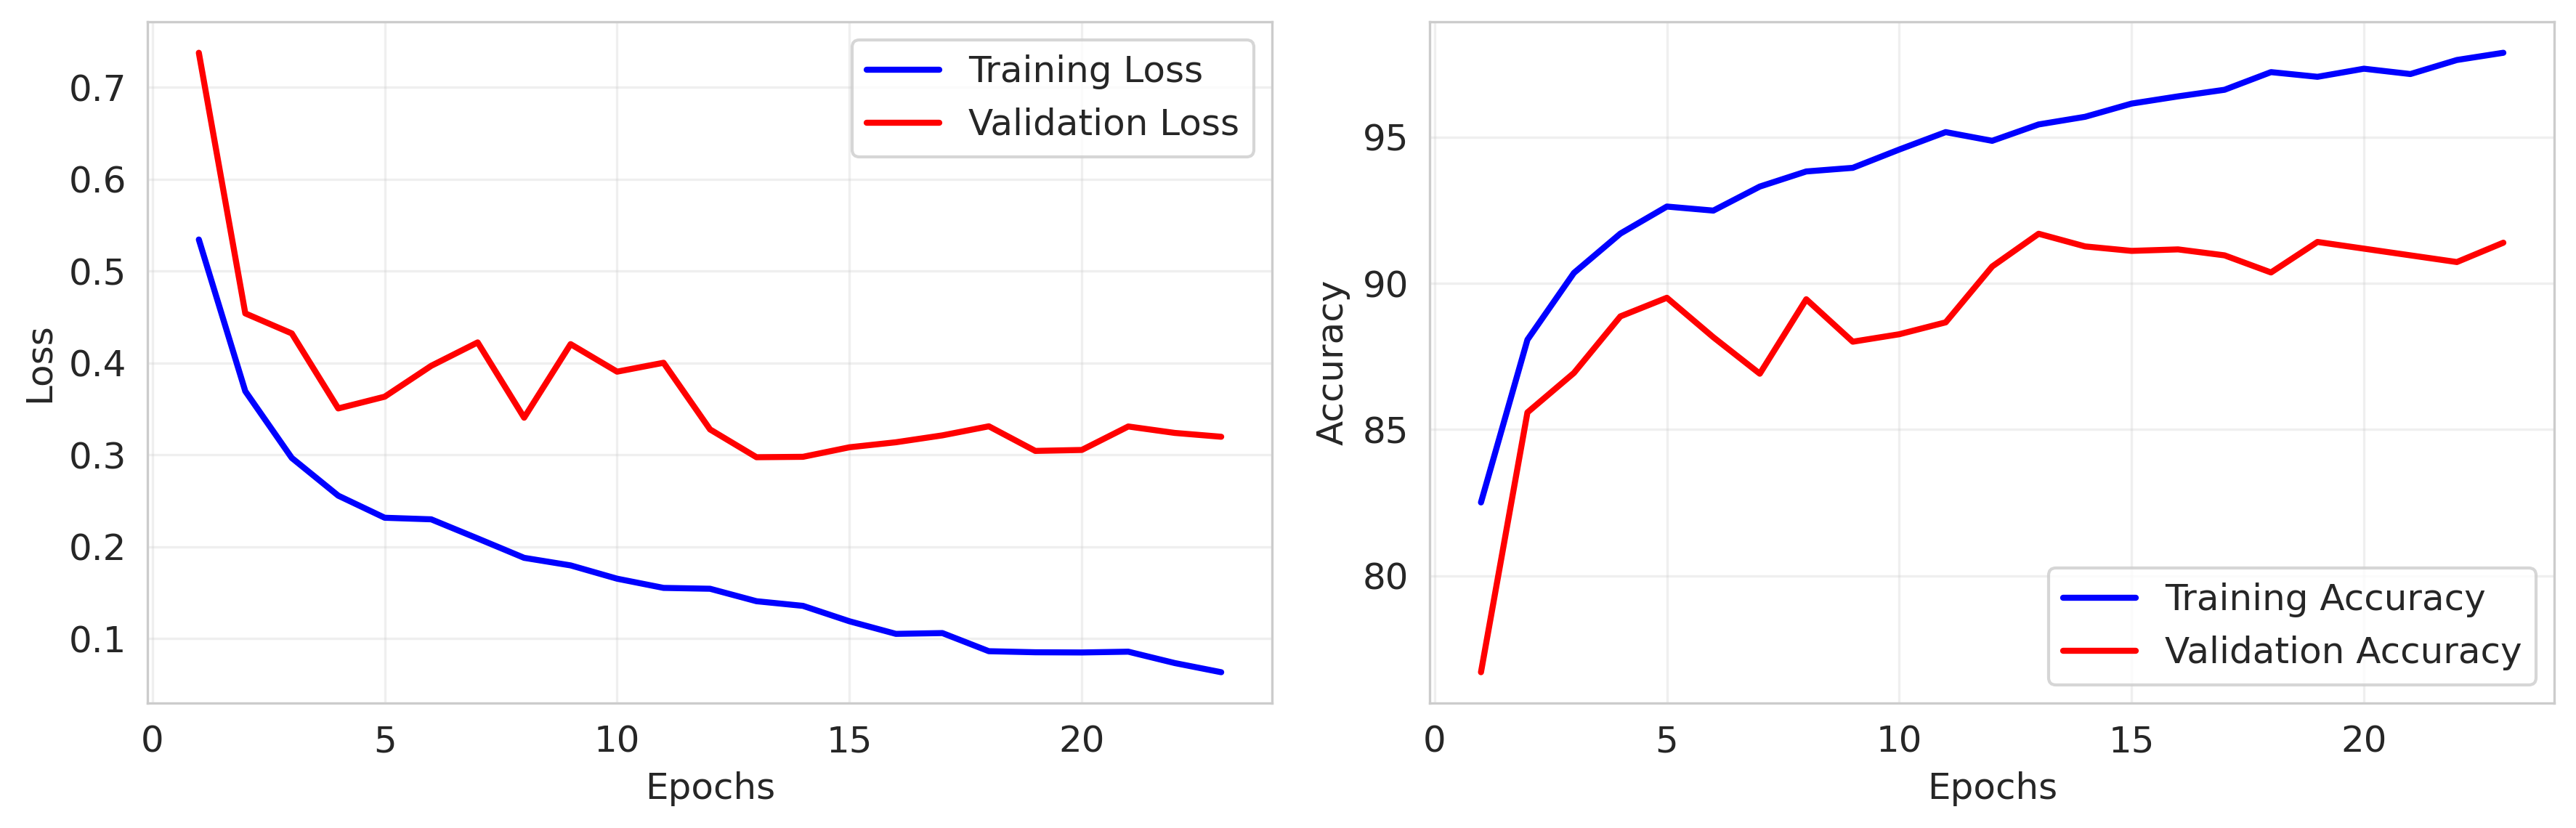


Learning curves of freeze mode up_to_layer1 and for fraction 100%


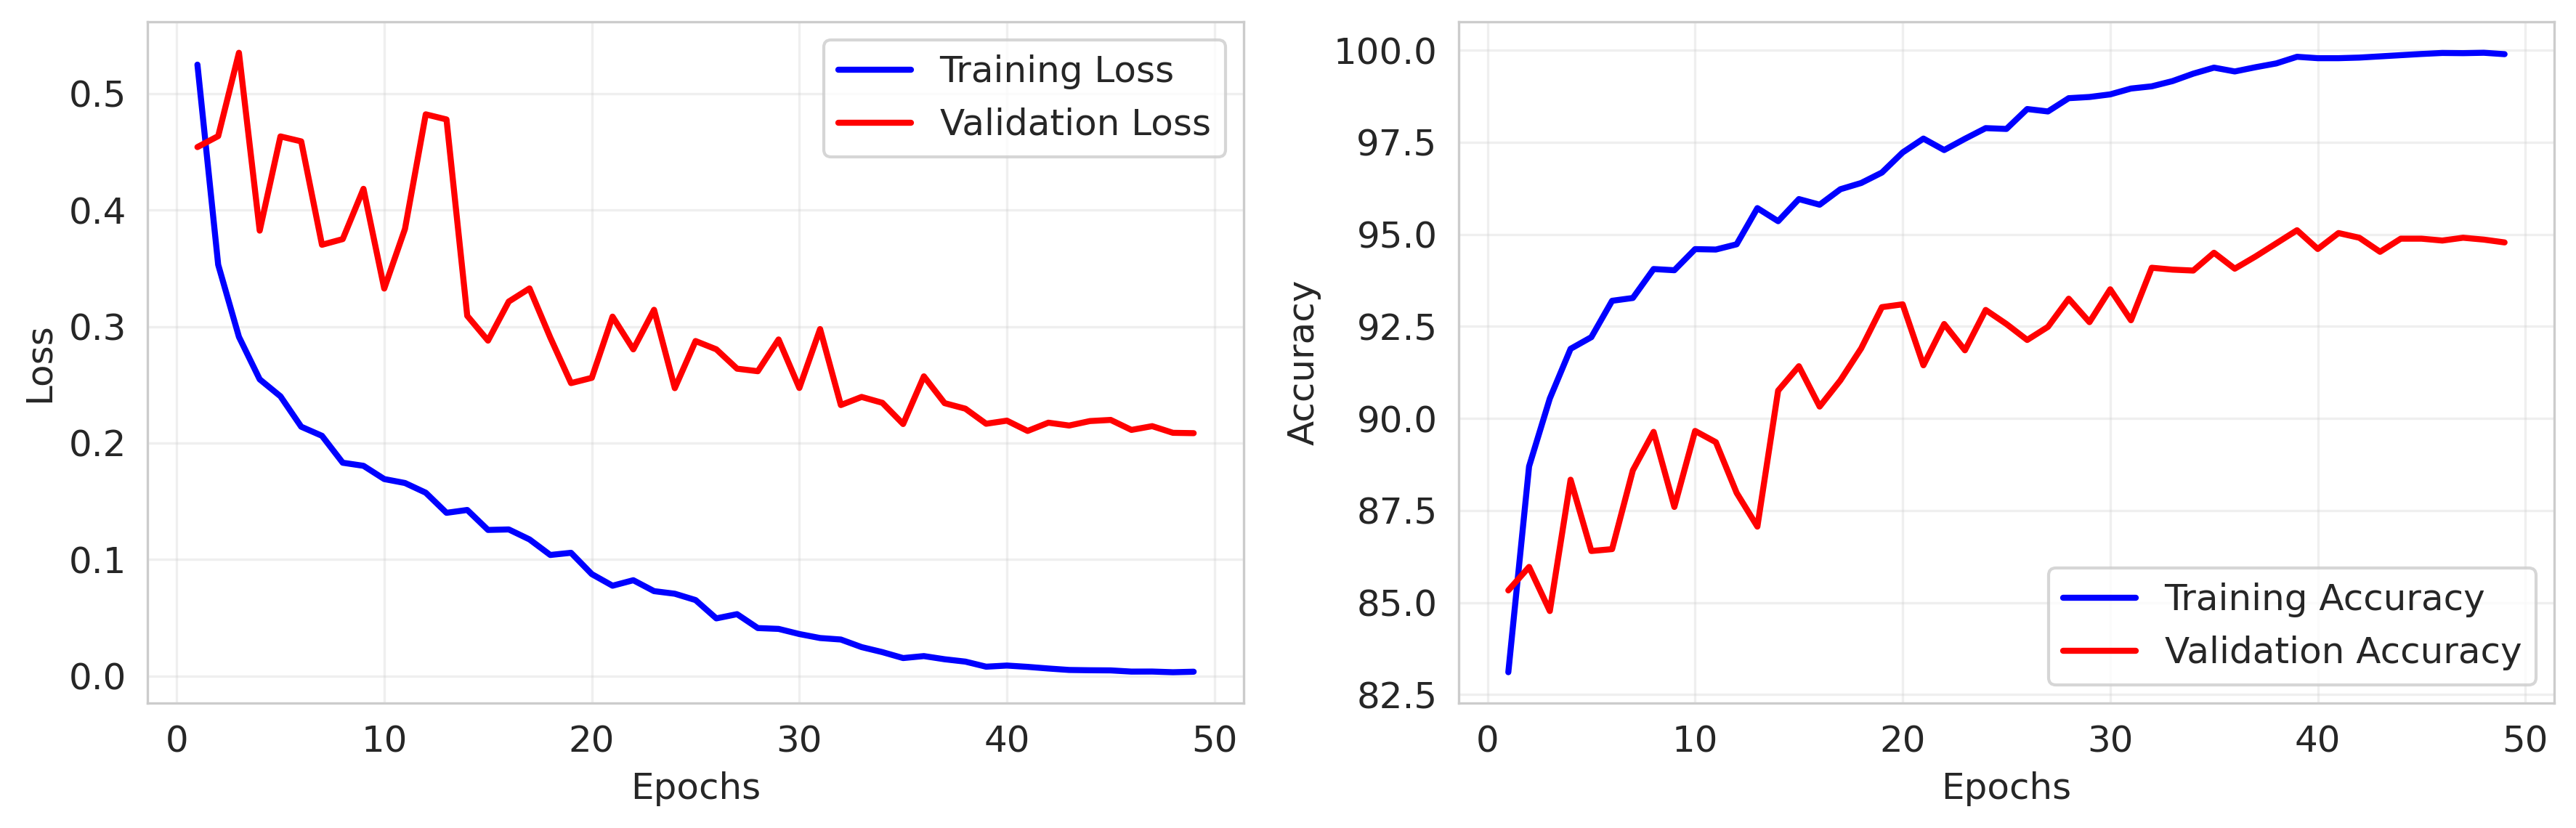


Learning curves of freeze mode up_to_layer2 and for fraction 10%


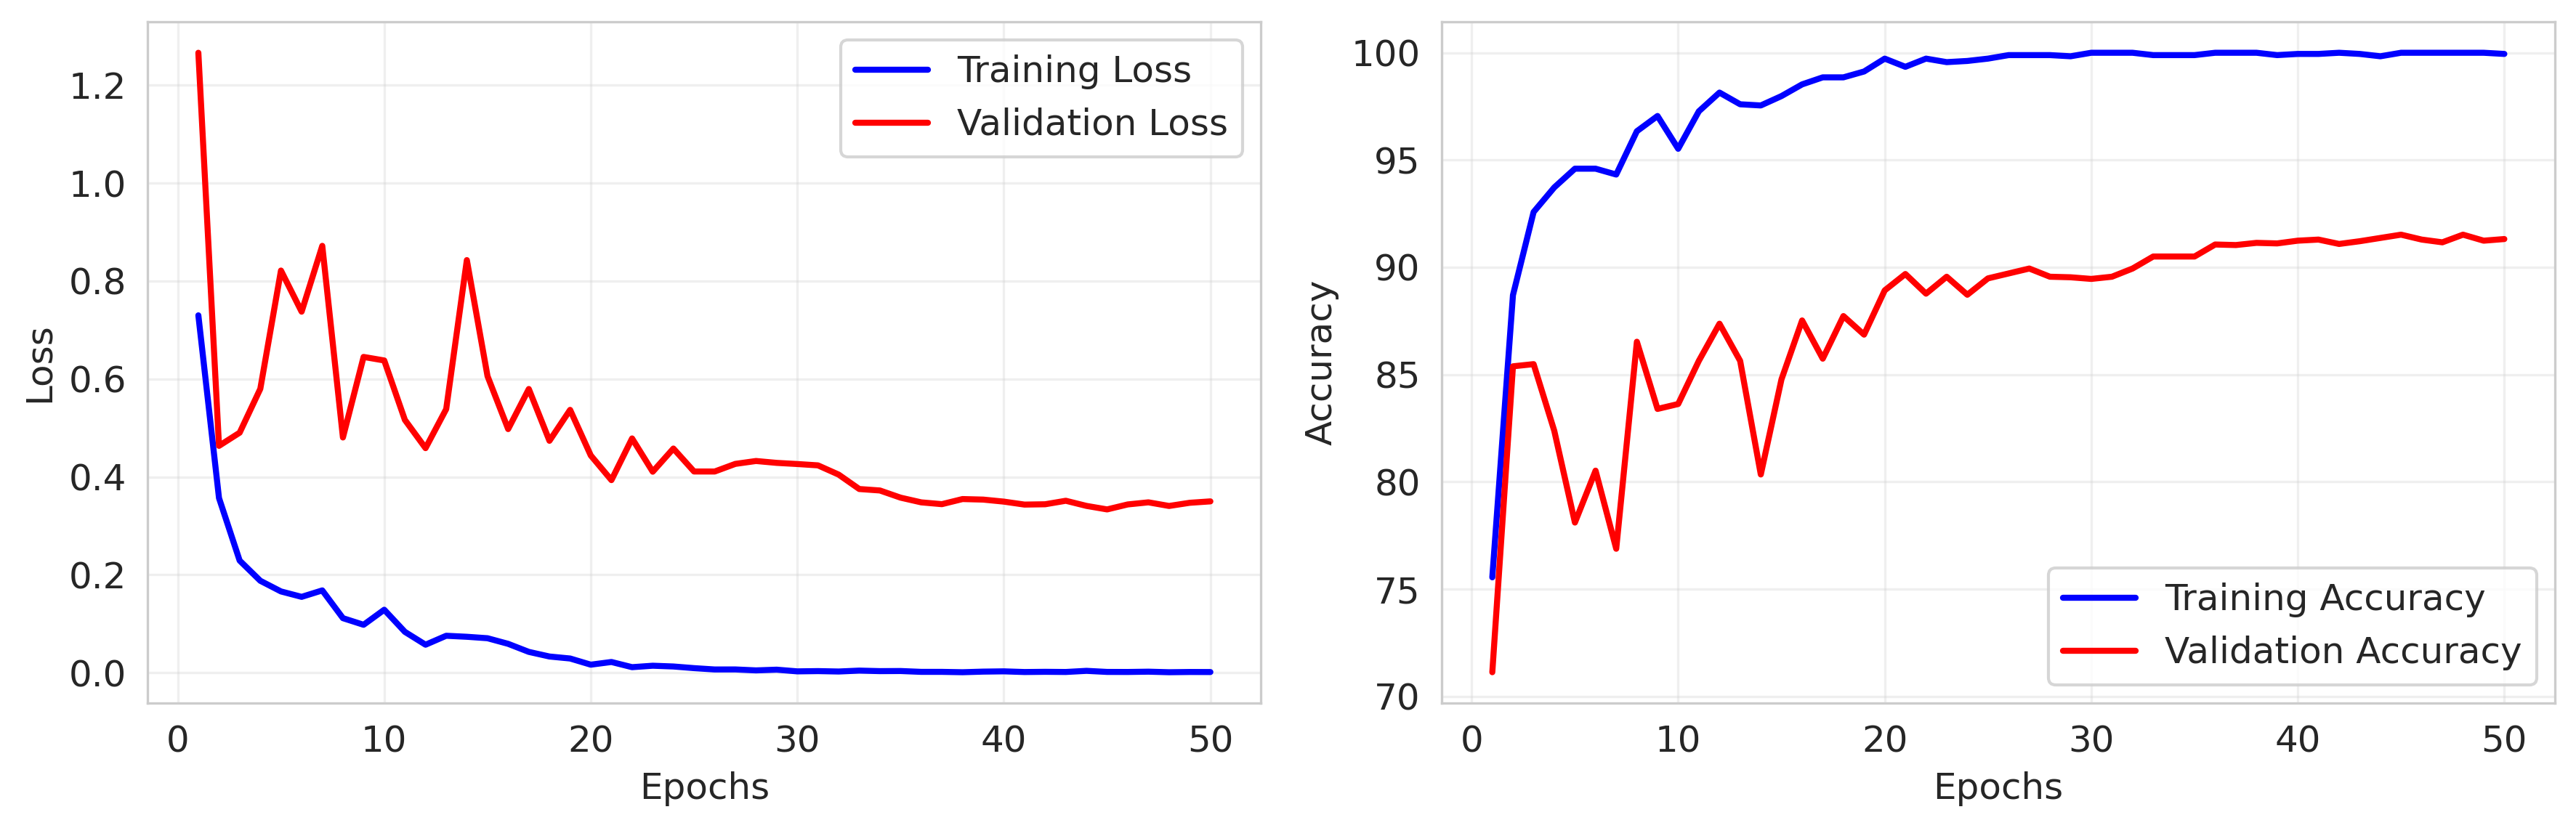


Learning curves of freeze mode up_to_layer2 and for fraction 25%


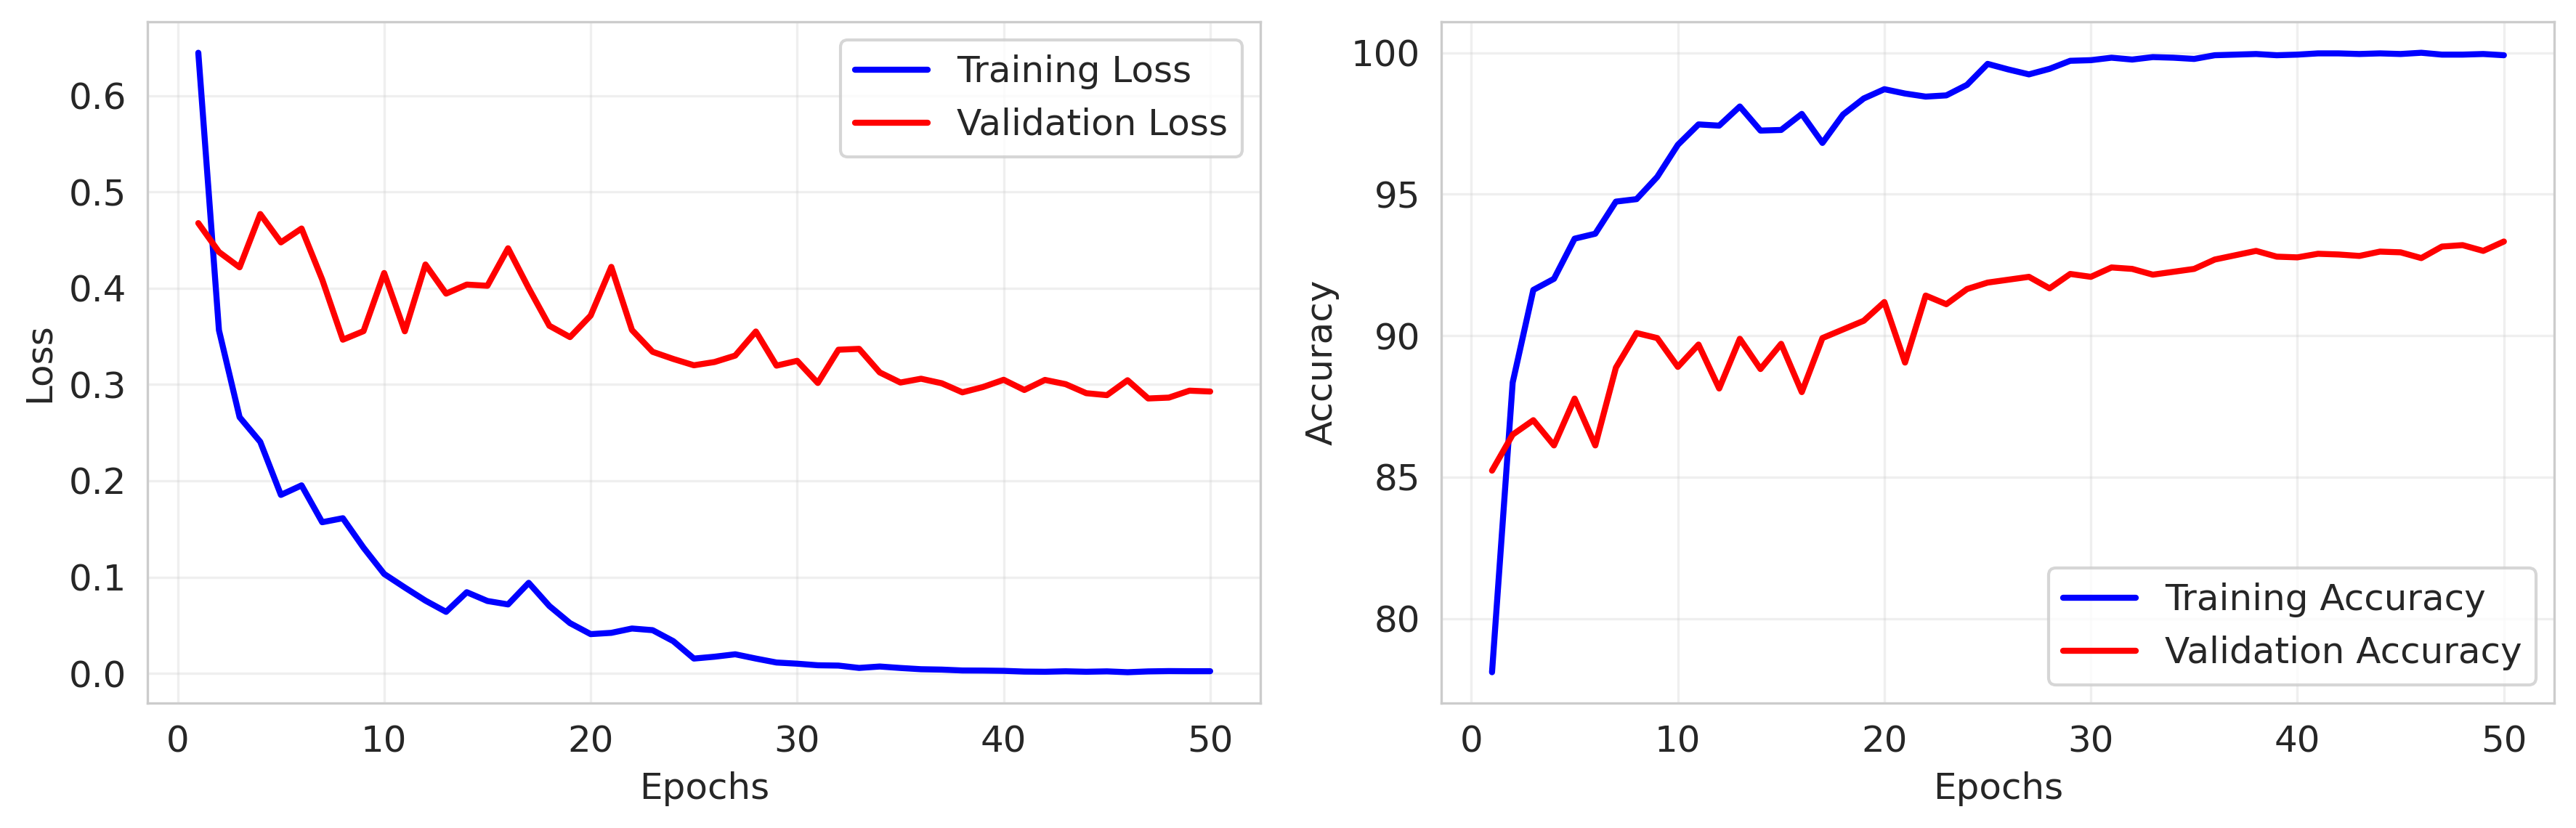


Learning curves of freeze mode up_to_layer2 and for fraction 50%


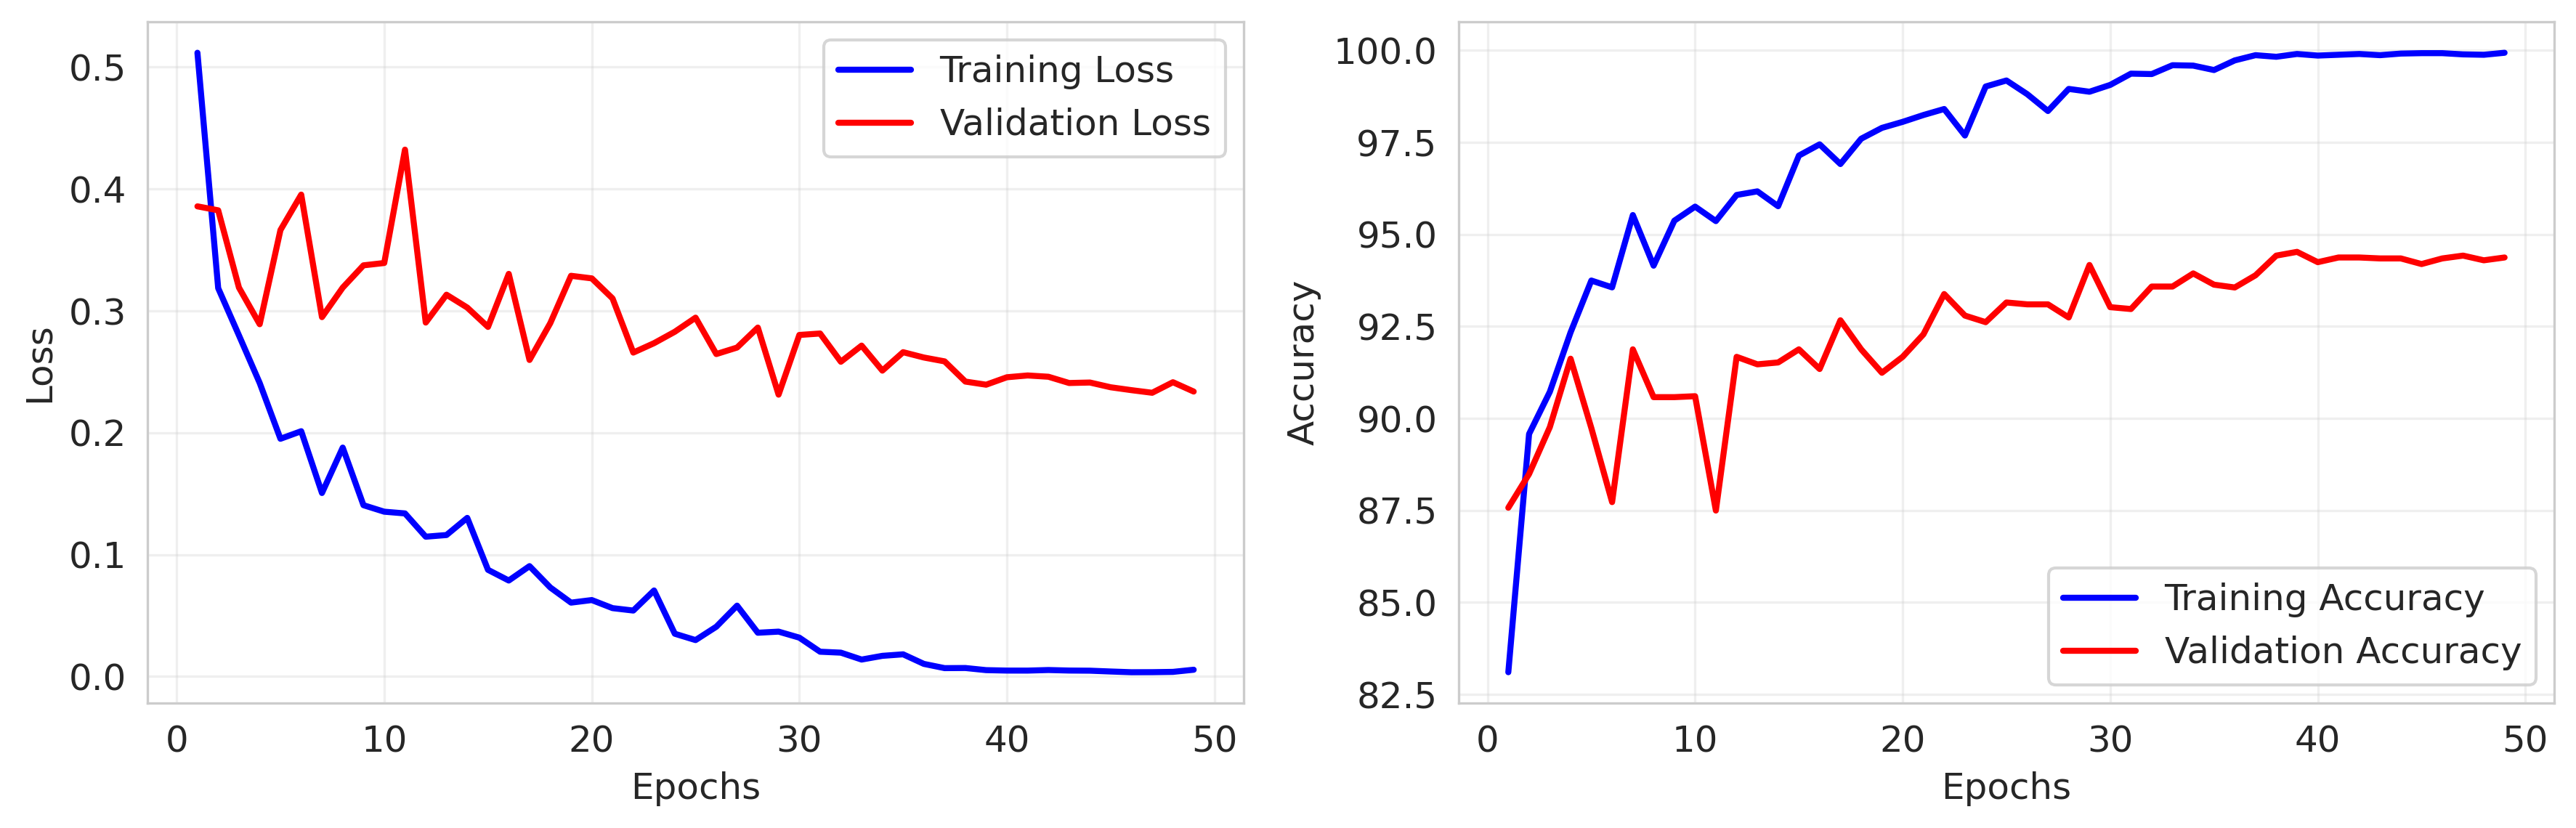


Learning curves of freeze mode up_to_layer2 and for fraction 75%


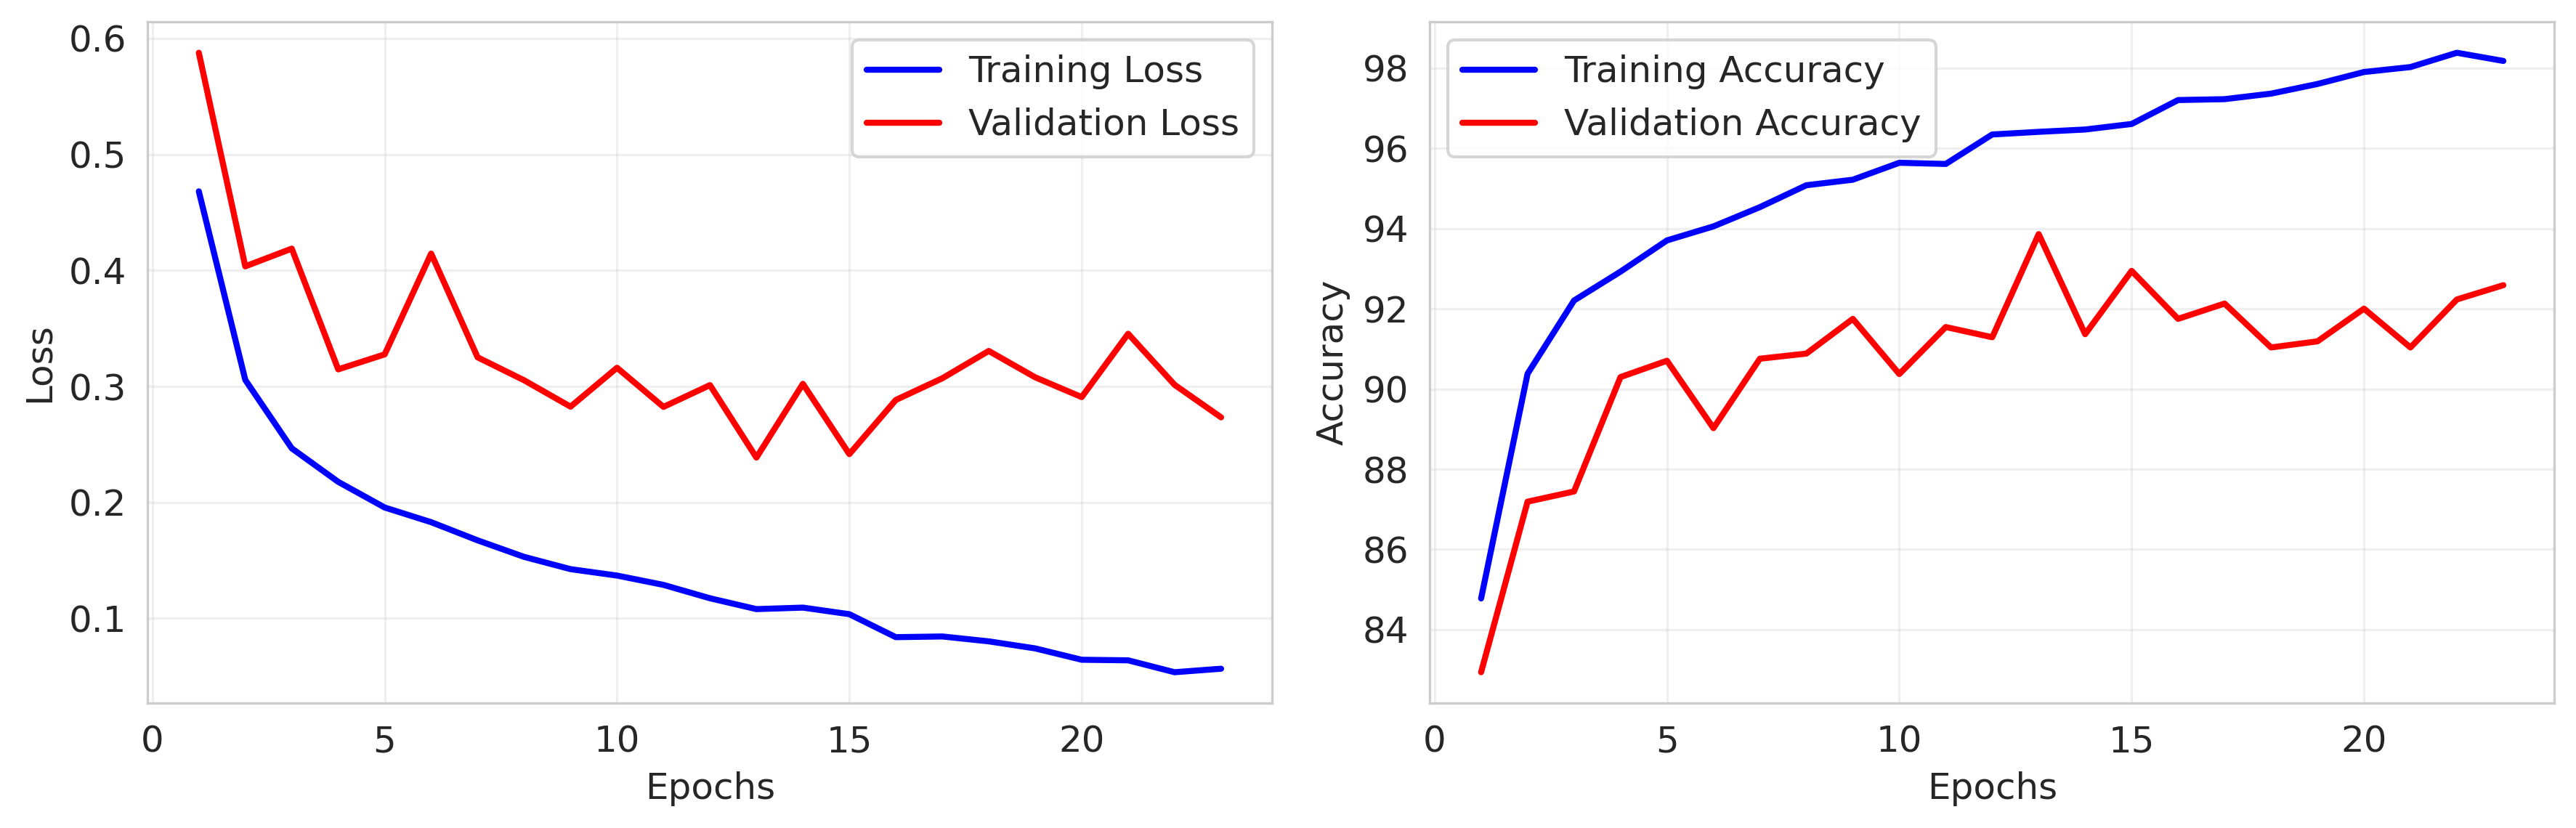


Learning curves of freeze mode up_to_layer2 and for fraction 100%


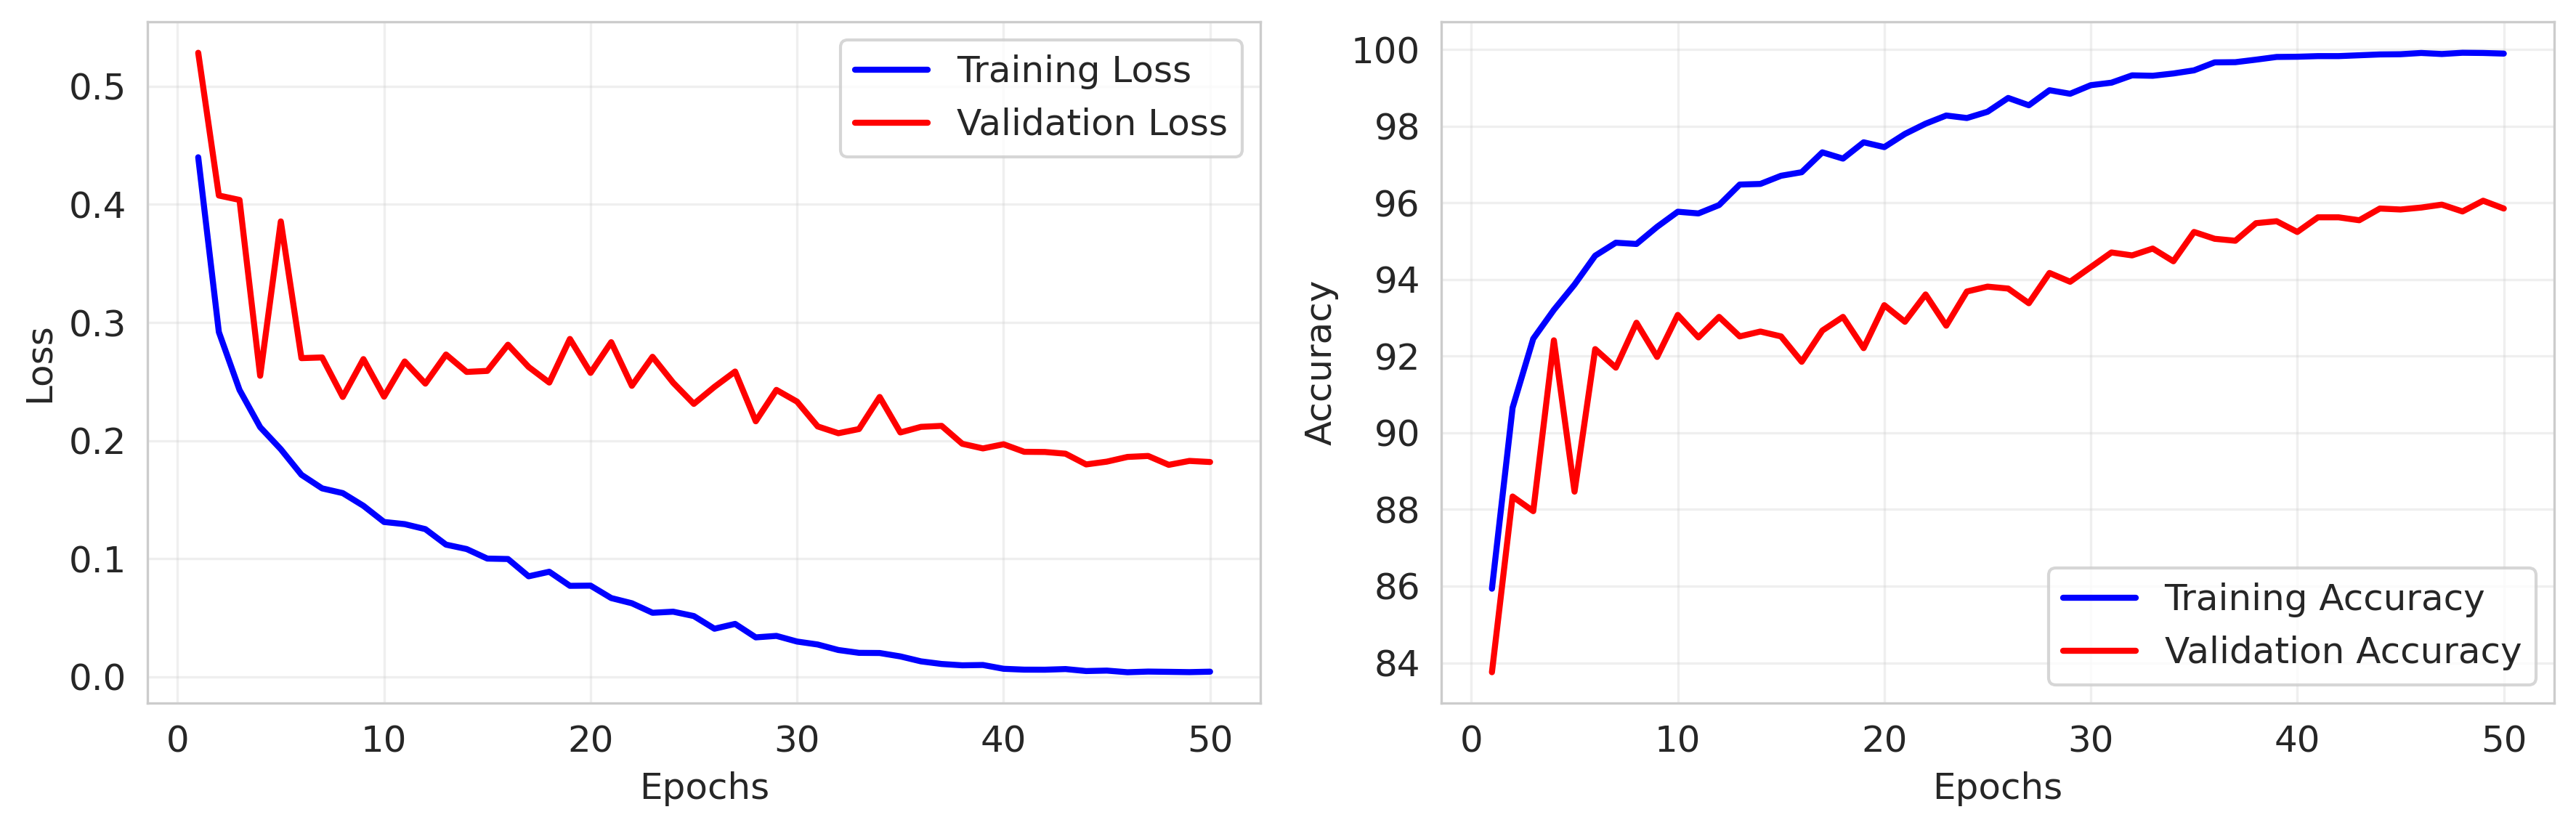


Learning curves of freeze mode up_to_layer3 and for fraction 10%


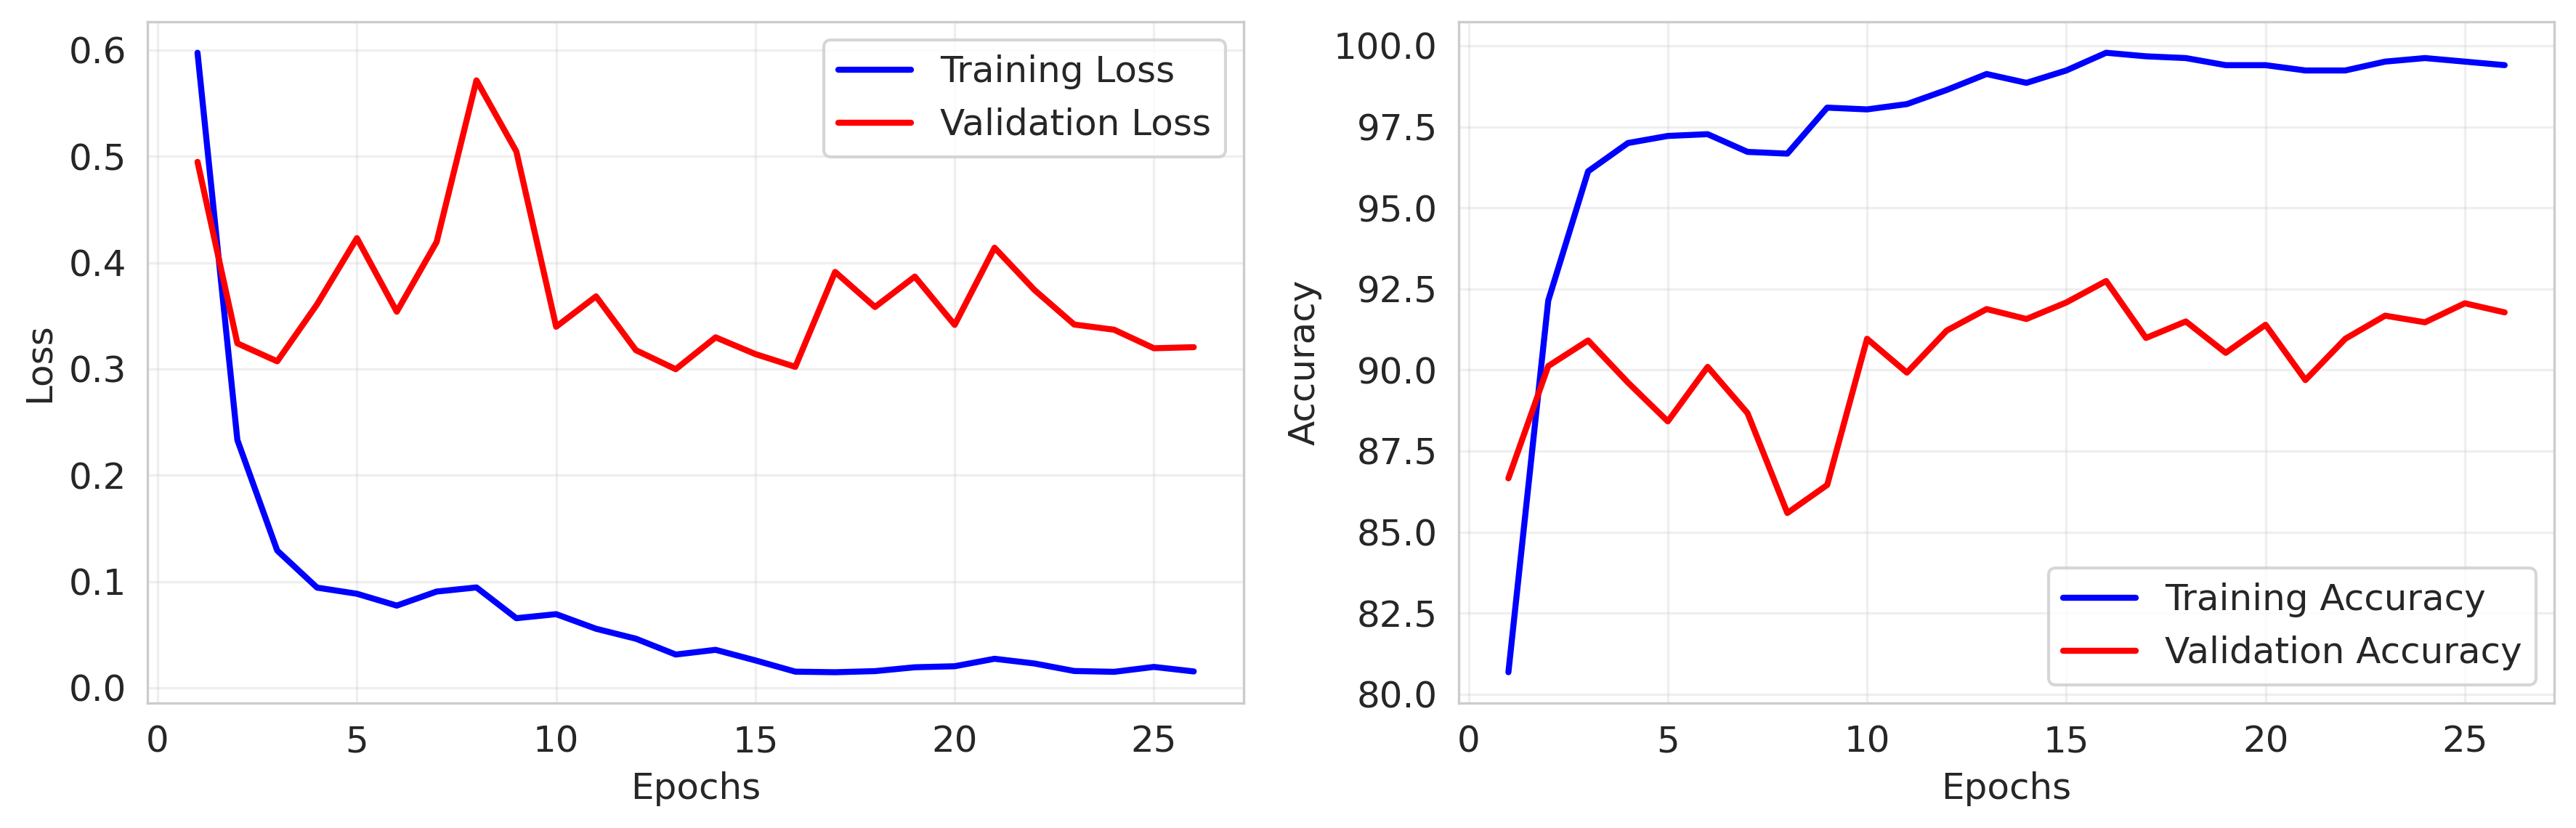


Learning curves of freeze mode up_to_layer3 and for fraction 25%


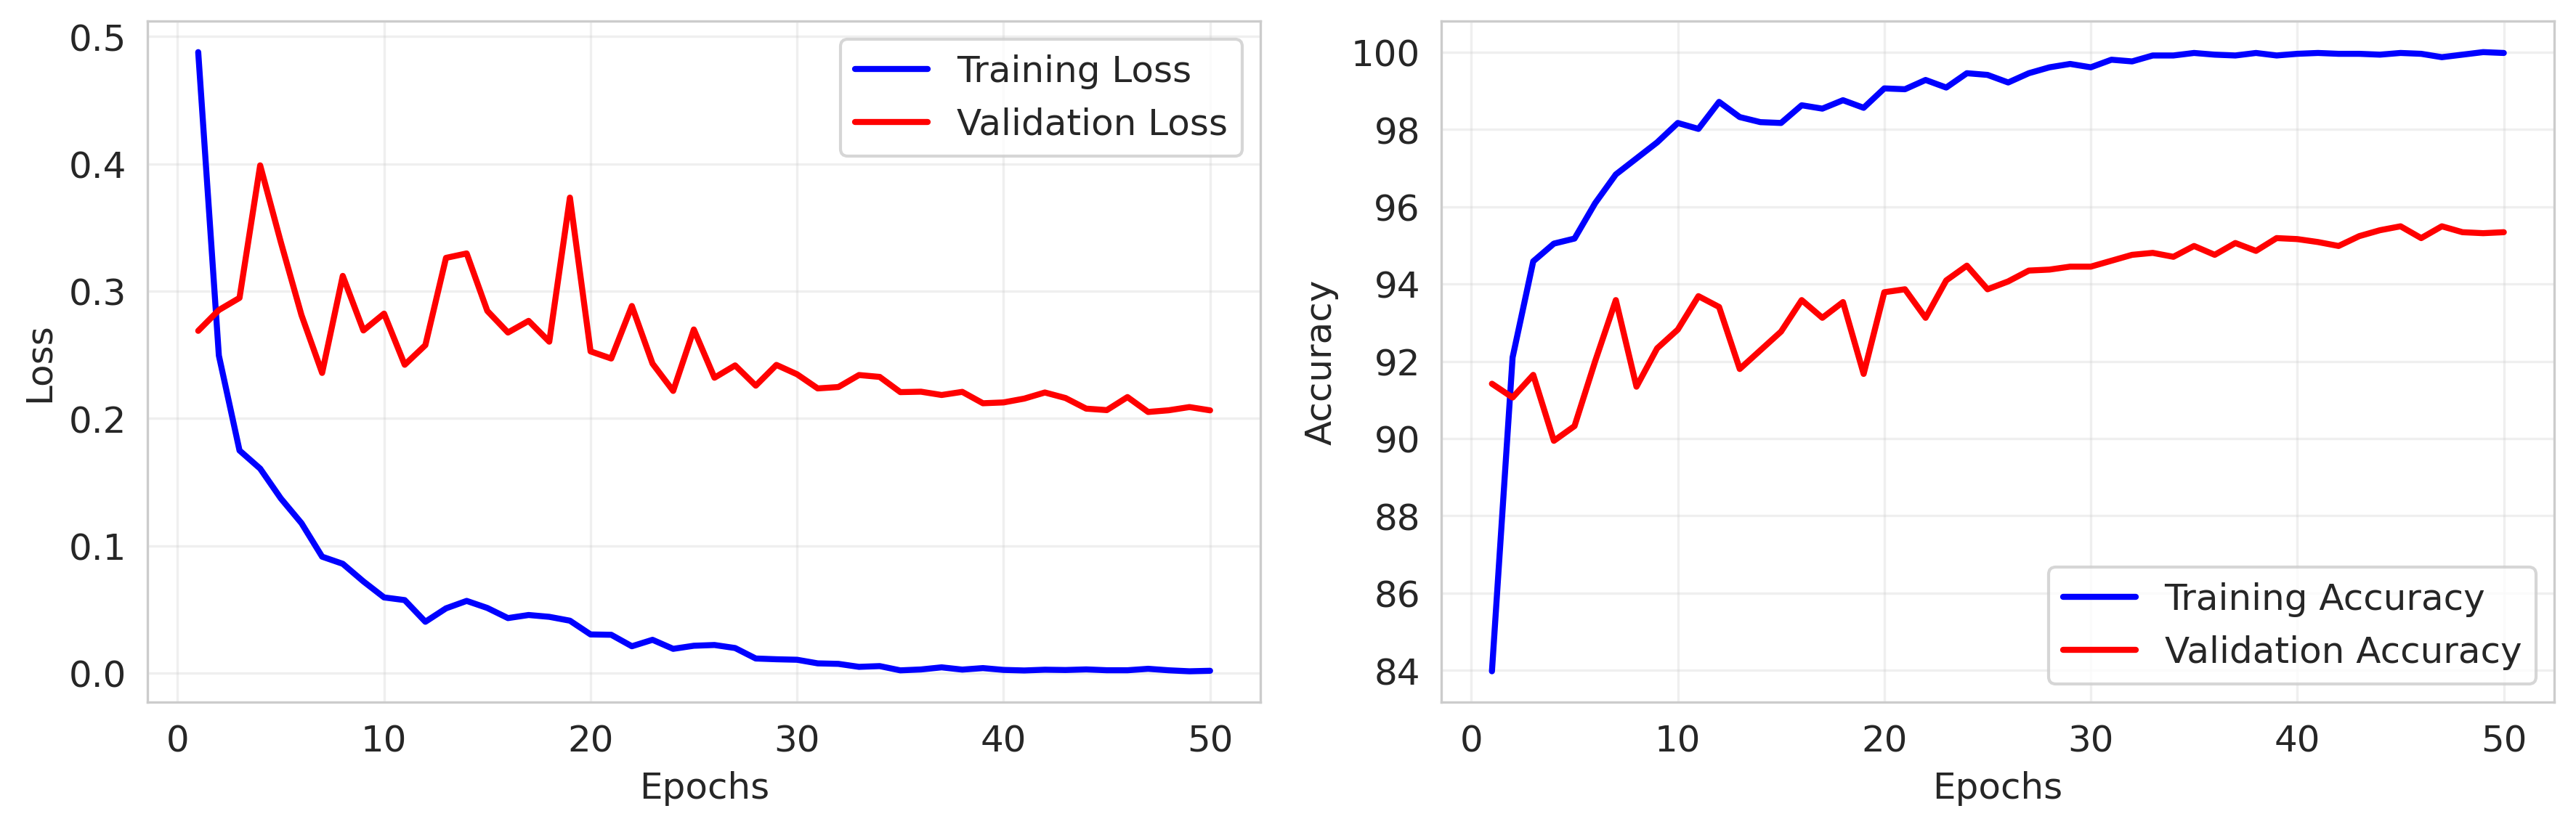


Learning curves of freeze mode up_to_layer3 and for fraction 50%


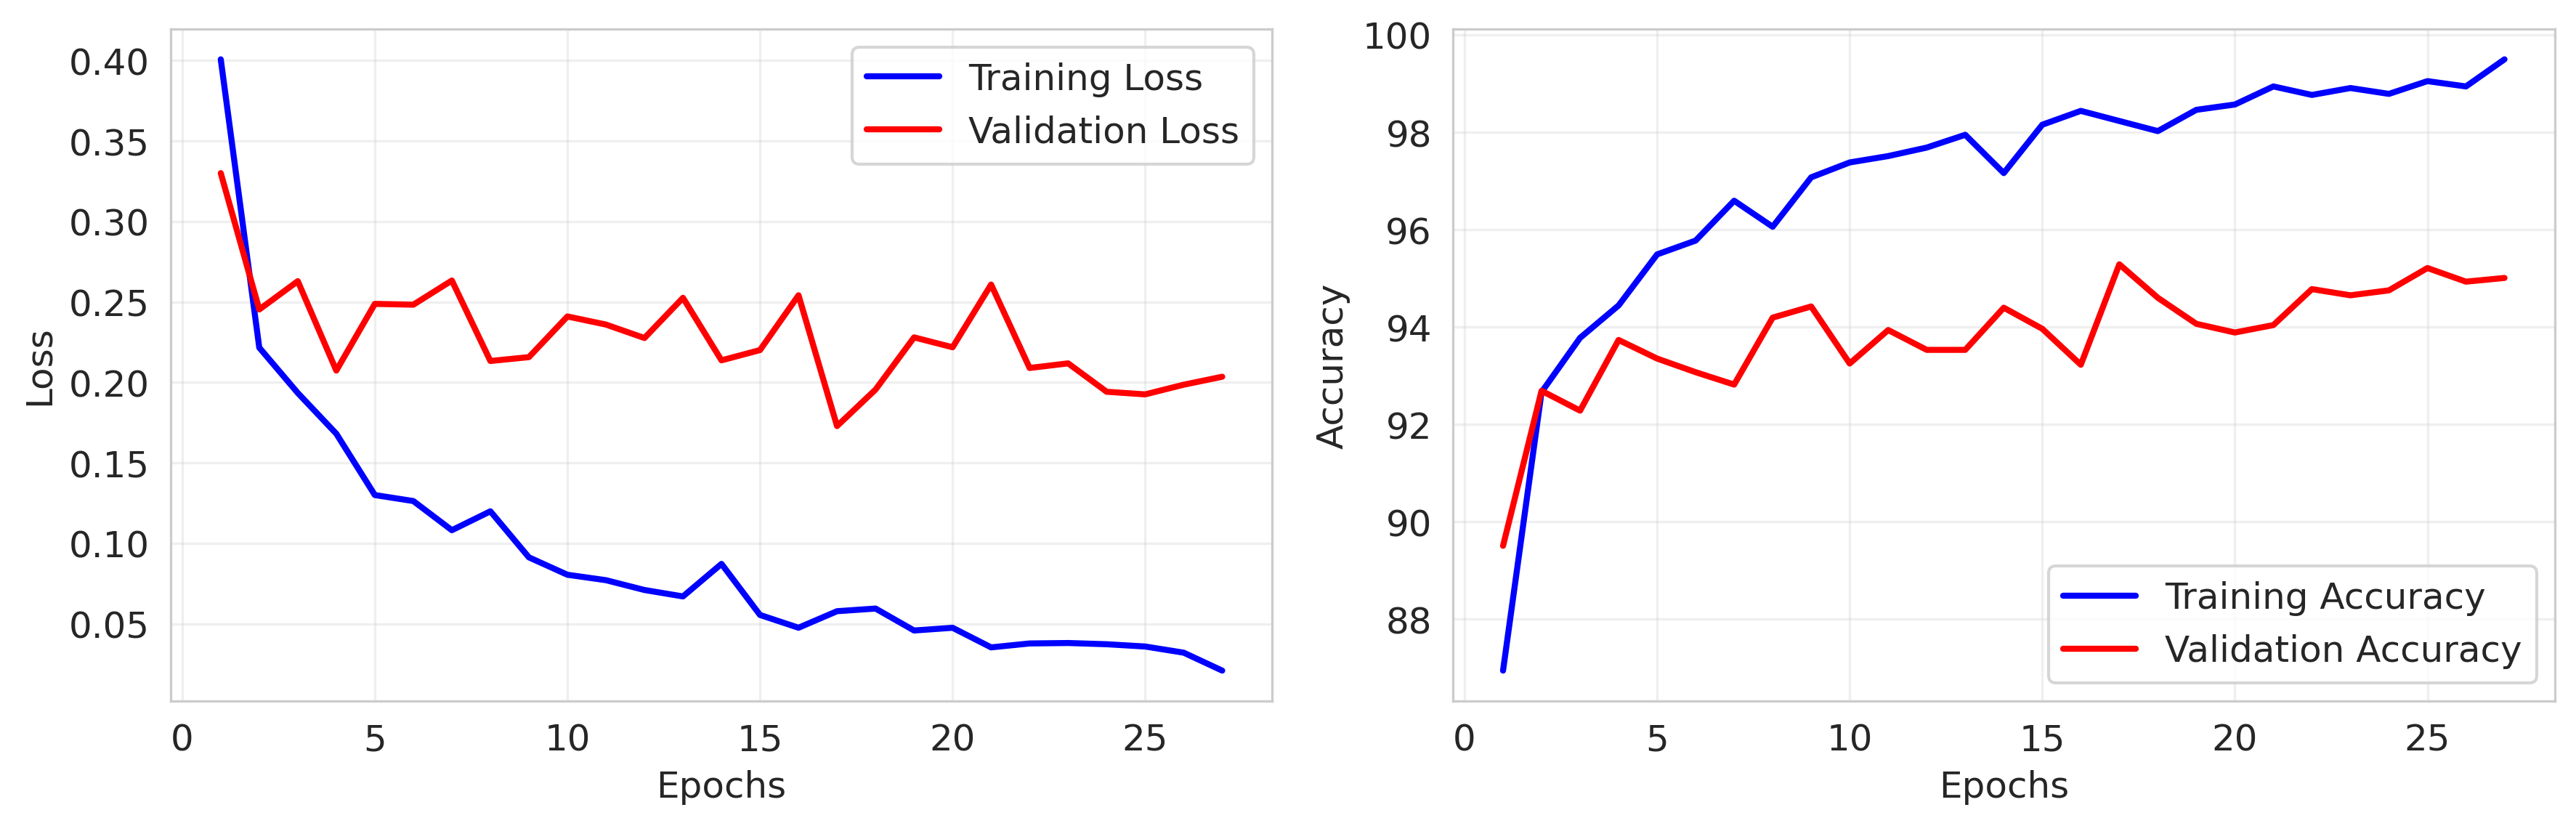


Learning curves of freeze mode up_to_layer3 and for fraction 75%


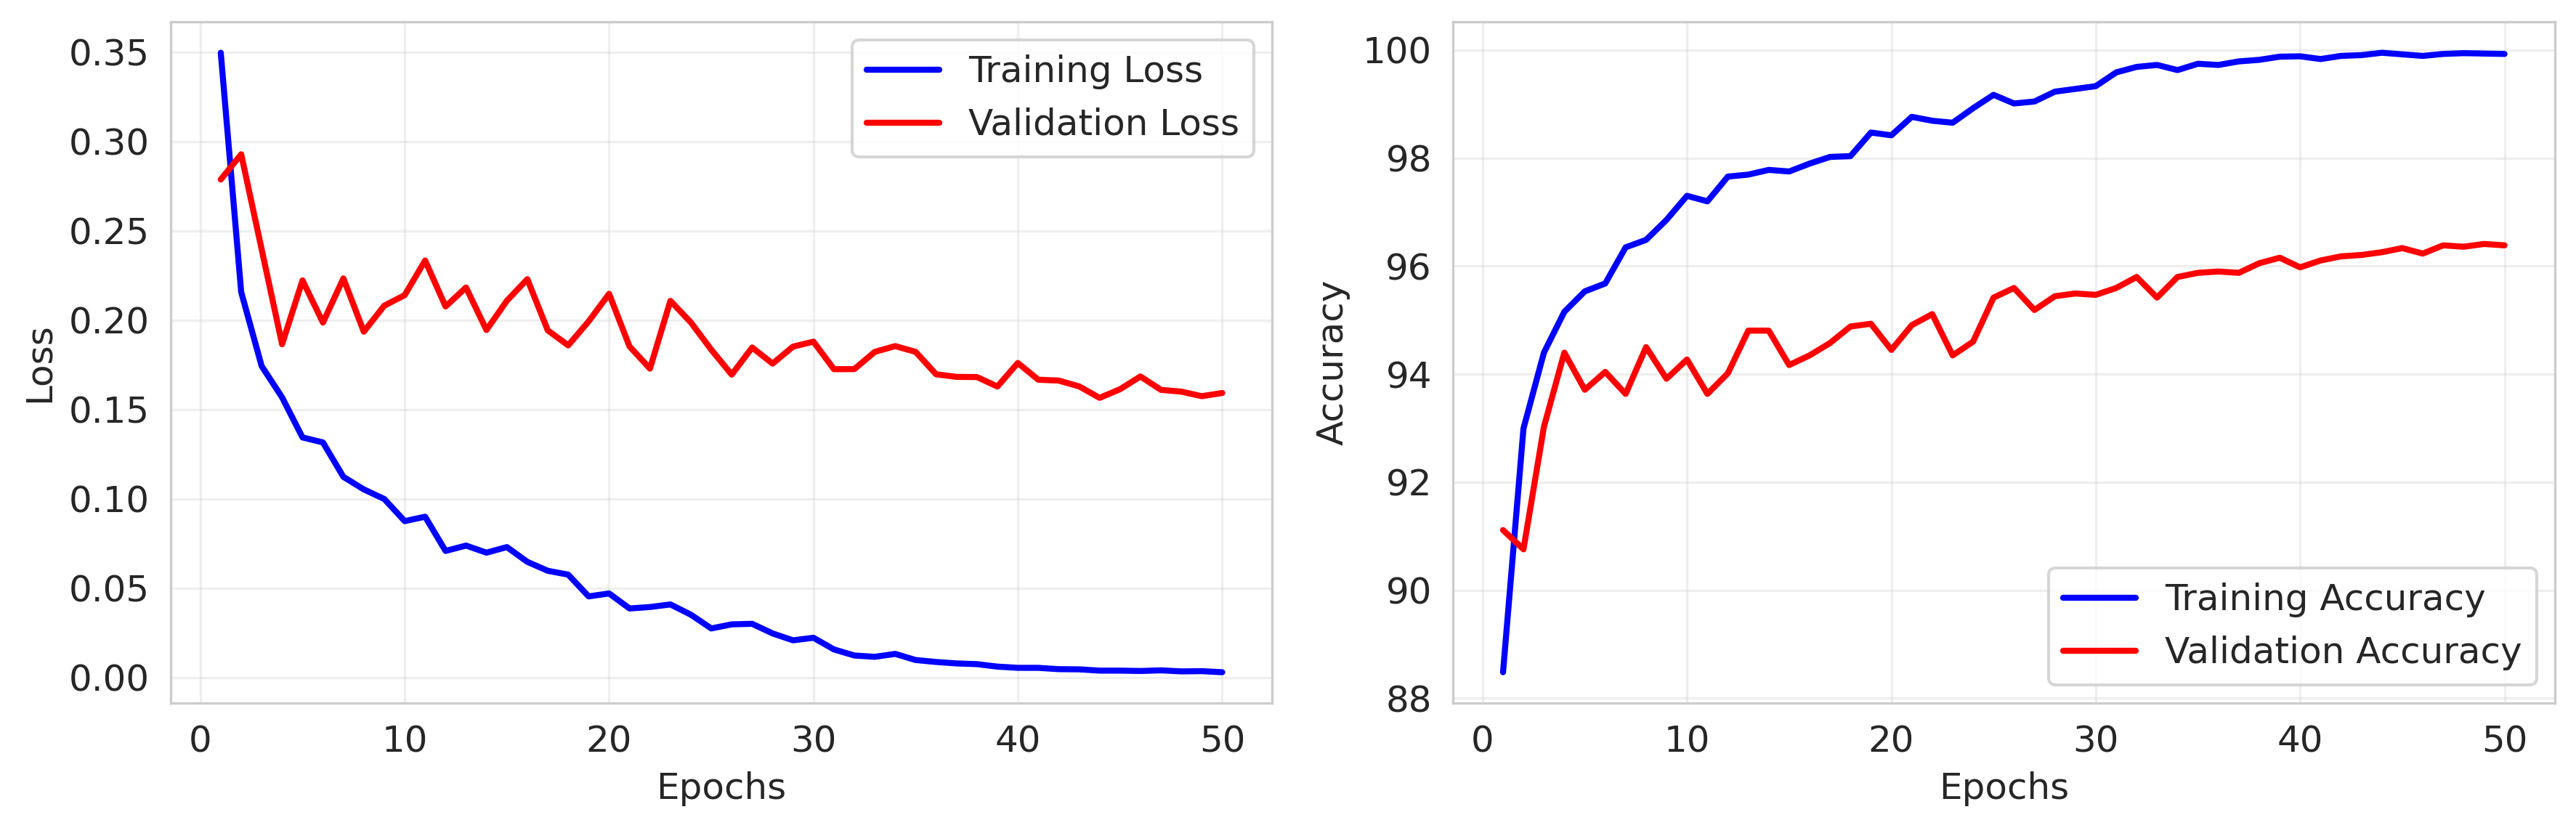


Learning curves of freeze mode up_to_layer3 and for fraction 100%


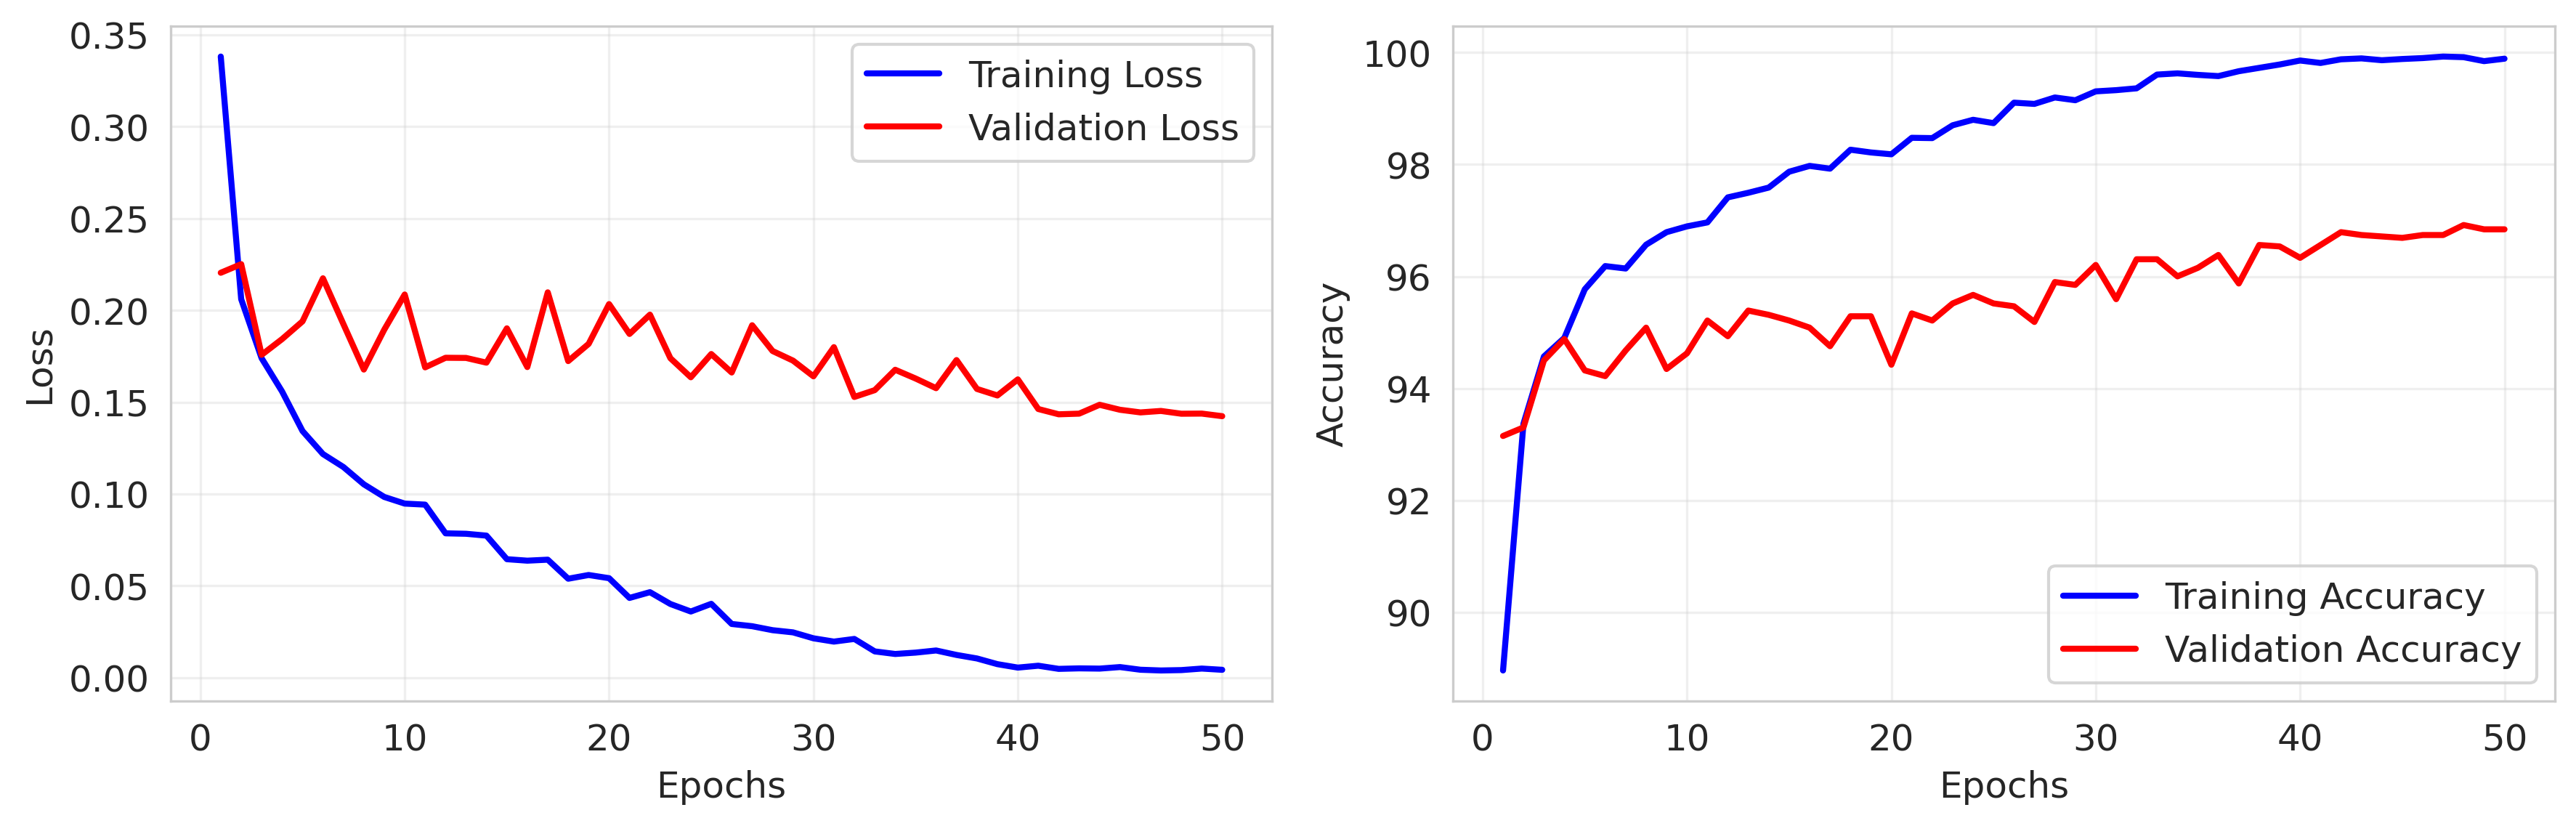

In [9]:
from IPython.display import Image, display

for freeze_mode in freeze_modes:
  for frac in data_fractions:
    plot_path = Config.PLOTS_DIR / f"task2_fine_tuned_{freeze_mode}_{frac:.2f}.png"
    if plot_path.exists():
        print(f"\nLearning curves of freeze mode {freeze_mode} and for fraction {frac*100:.0f}%")
        display(Image(filename=str(plot_path)))
    else:
        print(f"Plot not found for fraction {frac:.2f}: {plot_path}")

In [10]:
!zip -r results_task2_42.zip /content/TOL506M_Final_Project/results/

  adding: content/TOL506M_Final_Project/results/ (stored 0%)
  adding: content/TOL506M_Final_Project/results/plots/ (stored 0%)
  adding: content/TOL506M_Final_Project/results/plots/task2_fine_tuned_up_to_layer3_0.75.png (deflated 11%)
  adding: content/TOL506M_Final_Project/results/plots/task2_fine_tuned_all_but_fc_0.75.png (deflated 13%)
  adding: content/TOL506M_Final_Project/results/plots/task2_fine_tuned_up_to_layer1_0.50.png (deflated 11%)
  adding: content/TOL506M_Final_Project/results/plots/task2_fine_tuned_up_to_layer3_0.10.png (deflated 10%)
  adding: content/TOL506M_Final_Project/results/plots/task2_fine_tuned_up_to_layer1_0.75.png (deflated 12%)
  adding: content/TOL506M_Final_Project/results/plots/task2_fine_tuned_up_to_layer1_0.25.png (deflated 10%)
  adding: content/TOL506M_Final_Project/results/plots/task2_fine_tuned_up_to_layer3_0.50.png (deflated 10%)
  adding: content/TOL506M_Final_Project/results/plots/task2_fine_tuned_up_to_layer1_0.10.png (deflated 11%)
  adding: 

In [11]:
from google.colab import files
files.download("results_task2_42.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>